# 청년의 대사이상 위험 선별
## 초기 기준선에서 EPF 공동분포 모델까지

**연구 질문은 “채혈 없이 얻는 정보로 어떤 대사이상 소견이 있을지 미리 가늠할 수 있을까?”입니다.** 이 문서는 간단한 선별 모델을 만드는 과정과, 여러 검사값의 분포를 함께 예측하도록 확장한 과정을 순서대로 설명합니다.

<a id="part-1"></a>
## 1부. 전체 그림과 읽는 법

처음에는 **4,680명·11개 입력으로 ‘소견 하나 이상’**을 예측했습니다. 후속 연구에서는 별도로 정한 **4,068명·114열 입력으로 네 소견과 다섯 검사값의 공동분포**를 다뤘습니다. 두 연구는 대상·정답·평가가 달라 각각의 비교 안에서 결과를 읽어야 합니다.

| 읽는 목적 | 바로 볼 곳 |
|---|---|
| 결론을 먼저 파악하기 | 아래의 한눈에 보는 답 → [6부 결론과 한계](#part-6) |
| 자료에서 모델까지 따라가기 | [2부 초기 분석 만들기](#part-2) → [3부 결과 해석](#part-3) |
| EPF가 실제로 어떻게 움직이는지 이해하기 | [4부 구조와 공동분포](#part-4) |
| v28의 성능과 가설 판정을 확인하기 | [5부 같은 조건에서 비교하기](#part-5) |
| 저장된 표·그림을 다시 만들기 | [실행과 출처](#reproduce) |

각 분석은 **질문 → 코드의 역할 → 저장된 결과 → 해석** 순으로 읽습니다. 수식은 4부에서 기호를 먼저 설명한 뒤 제시하므로, 전체 흐름을 먼저 읽고 다시 돌아와도 됩니다.


### 한눈에 보는 답

| 질문 | 확인한 결과 | 읽을 때의 범위 |
|---|---|---|
| 간단한 11개 정보로 선별할 수 있었나? | 초기 로지스틱 회귀 ROC-AUC **0.804777**, AP **0.695022** | 기본 설정, 한 번의 70:30 분할에서 네 모델 중 가장 높았음 |
| 후속 v28에서 AP가 가장 높은 칸은? | **joint EPF: macro AP 0.381397** | 같은 v28 비교 안의 관측 순위이며 정확도 38.1%라는 뜻은 아님 |
| 소견 조합의 확률까지 가장 좋았나? | 16상태 NLL 최저는 **joint Linear: 1.359474** | AP와 NLL은 서로 다른 예측 성질을 평가함 |
| joint 설계의 개선 기준 H1을 충족했나? | 다섯 구조 중 **4개** 충족 | ‘다섯 개 모두’라는 전체 H1은 미충족 |
| EPF 내부 구조의 차이가 작다는 H2는? | **noP·step1 두 대조**는 사전 한계 안에 있음 | MLP·Linear까지 포함한 전체 조건은 미충족 |

따라서 현재 답은 **공동분포 설계에서 유리한 관측 패턴이 있었지만, EPF 고유 기전의 우월성이나 사전 전체 결합 기준의 충족을 입증하지는 못했다**입니다. 초기 기준선의 높은 AUC와 후속 macro AP를 직접 빼서 개선·저하를 계산할 수 없습니다.


### 두 연구를 구분하는 약속

**코호트**는 같은 기준으로 뽑아 분석하는 사람들의 집합입니다. 이름이 비슷해도 코호트와 정답이 바뀌면 같은 시험 문제가 아닙니다.

| 항목 | 초기 기준선: 2–3부 | 후속 v28: 4–5부 |
|---|---|---|
| 자료 | KNHANES 2021–2024년 | 같은 연도 자료에서 별도로 고정한 코호트 |
| 최종 대상 | 19–39세 **4,680명** | **4,068명** |
| 대상 기준 | 치료 중인 사람 제외, 입력 결측 제거 | 진단 없음·약물복용 기준, 12시간 이상 금식, 다섯 검사값 완전성, 유효 조사 가중치·PSU·층 기준 |
| 입력 | 비침습 변수 **11개** | 원시 변수 **38개**를 fit 전용 전처리하여 **114열** |
| 학습 정답 | 네 소견 중 하나 이상인지: 0/1 하나 | binary: 네 소견 / joint: 다섯 연속 검사값 |
| 분리 | 학습 3,276명 / 시험 1,404명 | PSU가 섞이지 않는 5-fold와 고정 역할 |
| 대표 지표 | 단일 Target의 ROC-AUC·AP | 조사 가중 네 소견 AP의 평균인 macro AP |
| 비교 모델 | 로지스틱·RF·XGBoost·LightGBM | binary/joint × Linear·MLP·EPF·noP·step1 |

**114열은 114개의 독립적인 임상 측정이 아닙니다.** 범주 인코딩 등으로 38개 원시 입력을 모델이 받을 숫자 열로 바꾼 결과입니다. 이 문서의 후속 성능 비교는 [v28 고정 조건](../v28/PROTOCOL.md) 안에서 이루어집니다.


### 먼저 알아둘 데이터·학습 용어

| 용어 | 이 문서에서의 뜻 |
|---|---|
| 입력 `X` / 정답 `y` | 모델에 보여 주는 정보 / 학습과 평가에서 맞춰 볼 관측 결과 |
| 전처리 | 결측 처리, 숫자 크기 조절, 범주 인코딩 등 입력을 준비하는 과정 |
| fit | 가중치와 전처리 기준을 실제로 배우는 자료 역할 |
| validation | 학습 중 어느 시점의 모델을 선택할지 판단하는 자료 역할 |
| test | 선택이 끝난 모델의 성능을 평가하는 자료 역할 |
| fold | 교차검증의 한 분할. v28은 다섯 test 묶음을 차례로 평가함 |
| OOF | 각 사람이 자신을 fit에 쓰지 않은 해당 fold 모델에서 받은 시험 예측을 모은 것 |
| seed | 초기 난수 상태를 정하는 번호. v28은 다섯 seed의 예측을 평균함 |
| epoch / checkpoint | fit 자료를 한 차례 학습한 단위 / 특정 시점에 저장한 모델 상태 |
| PSU / 층 / 조사 가중치 | 함께 표집된 집락 / 표집 구분 / 각 표본이 대표하는 정도를 반영하는 값 |
| 과적합 | 학습 자료에는 잘 맞지만 새 자료에서 성능이 유지되지 않는 현상 |

**같은 사람의 정보를 답안 선택에 미리 쓰지 않는 것**이 평가의 기본입니다. v28은 사람뿐 아니라 PSU가 역할 사이에 섞이지 않도록 나누며, 전처리 기준도 fit 자료에서만 정합니다. 초기 분석은 더 단순한 한 번의 학습/시험 분할입니다.


### 먼저 알아둘 점수와 불확실성

**확률을 잘 정렬하는 것**, **한 기준에서 잘 분류하는 것**, **확률 숫자가 실제 빈도와 맞는 것**은 서로 다른 질문입니다.

| 지표 | 질문 | 읽는 방향 |
|---|---|---|
| ROC-AUC | 위험군이 정상군보다 높은 점수를 받을 가능성이 큰가? | 높을수록 좋음; 동점은 절반으로 계산 |
| AP, average precision | 점수가 높은 사람부터 볼 때 양성 소견을 얼마나 잘 앞쪽에 모으는가? | 정밀도와 재현율을 함께 요약; 높을수록 좋음 |
| macro AP | 네 소견의 AP를 동등하게 평균하면 어떤가? | 각 소견에 1/4 비중; ‘맞힌 사람 비율’이 아님 |
| 민감도 / 특이도 | 특정 기준에서 실제 위험군 / 실제 정상군을 얼마나 찾는가? | 기준을 낮추면 보통 민감도는 높아지고 특이도는 낮아짐 |
| NLL, 음의 로그우도 | 실제 관측 결과에 충분한 확률을 주었는가? | 낮을수록 좋음; 작은 확률을 준 실제 결과에 큰 벌점 |
| 보정(calibration) | 0.3으로 예측한 집단에서 실제 비율이 약 30%인가? | AP가 높아도 보정이 좋다고 보장되지는 않음 |
| CI, 신뢰구간 | 자료의 표본 변동을 고려하면 추정이 어느 범위로 흔들리는가? | 계산 방법과 포함한 불확실성의 범위를 함께 확인 |

초기 코드의 `PR-AUC`는 `average_precision_score`로 계산한 **AP**입니다. PR 곡선을 사다리꼴로 적분한 값과 항상 같지는 않습니다. AP의 기준 수준은 양성률에 영향을 받으므로 서로 다른 정답·코호트의 AP를 그대로 비교하지 않습니다.

95% 신뢰구간은 같은 절차를 반복할 때의 포함 성질을 뜻합니다. 계산된 특정 구간에 참값이 95% 확률로 들어 있다고 단순 해석하지 않습니다. v28의 구간은 **고정된 OOF 예측을 PSU 단위로 재표집한 범위**이며, 자세한 범위는 H1·H2에서 설명합니다.


<a id="part-2"></a>
## 2부. 초기 분석: 자료에서 네 모델 비교까지
### 2.1 분석 도구 준비

**질문:** 원자료를 읽고 표로 묶어 계산하려면 무엇이 필요한가?

아래 셀은 도구를 불러옵니다. `pandas`는 행·열 표를 다루고, `numpy`는 숫자 계산을, `pyreadstat`는 SAS 원자료 읽기를 담당합니다. `os`는 파일 존재 여부 등을 확인합니다. `warnings.filterwarnings('ignore')`는 경고 표시를 숨기는 원본 설정이므로, 실행 환경을 점검할 때는 경고도 따로 살펴볼 필요가 있습니다.


In [2]:
import os,warnings,pyreadstat
import pandas as pd 
import numpy as np 
#pyreadstat(python + read + statistical data)으로 sas나 spss 파일 읽어오는 도구
warnings.filterwarnings('ignore')

# 사소한 버전 불일치 경고같은거 무시

### 2.2 원자료의 형태 확인

**질문:** 한 파일에 무엇이 들어 있는가?

국민건강영양조사(KNHANES)는 건강 설문·신체 계측·혈액검사 등의 자료를 제공합니다. 한 행은 한 사람, 한 열은 조사 항목입니다. 아래 셀은 **2024년 파일을 열어 크기와 열 이름을 확인**합니다. 저장된 크기는 **6,997행 × 813열**입니다.

원자료 네 파일 `hn21_all.sas7bdat`–`hn24_all.sas7bdat`는 별도로 확보해 저장소의 `data/raw/`에 두어야 합니다. 코드는 실행 위치가 저장소 루트 또는 `notebooks/`일 때 이 상대 경로를 사용합니다. 개인별 자료 미리보기는 공개본에 포함하지 않습니다.


In [ ]:
from pathlib import Path

run_dir = Path.cwd()
project_root = run_dir.parent if run_dir.name == 'notebooks' else run_dir
data_dir = project_root / 'data' / 'raw'
file_path = str(data_dir / 'hn24_all.sas7bdat')

df_24, meta = pyreadstat.read_sas7bdat(file_path)

print(f"2024년 데이터 크기: {df_24.shape}")
print("2024년 열 이름:", list(df_24.columns))

2024년 데이터 크기: (6997, 813)


### 2.3 필요한 변수만 모아 4개년 결합

**질문:** 선별 모델과 대상자 정의에 어떤 정보가 필요한가?

아래 코드는 연도별 파일에서 선택한 25개 열 중 존재하는 열을 모아 `df_all`로 합칩니다. **입력**, **대상자 제외 기준**, **정답을 만드는 검사값**의 역할을 구분해 두면 뒤의 흐름을 이해하기 쉽습니다.

| 변수 | 의미 | 분석에서의 역할 |
|---|---|---|
| `ID`, `year` | 개인 식별자, 조사연도 | 식별 |
| `age`, `sex` | 나이, 성별(1 남성·2 여성) | 입력 |
| `incm`, `edu` | 소득 4분위, 교육수준 4단계 | 입력 |
| `cfam` | 가구원 수 | 1인 가구 입력 생성 |
| `DI1_dg`, `DI1_pt` | 고혈압 진단, 치료 여부 | 이 코드에서는 치료 여부로 제외 |
| `DE1_dg`, `DE1_pt` | 당뇨병 진단, 치료 여부 | 동일 |
| `DI2_dg`, `DI2_pt` | 이상지질혈증 진단, 치료 여부 | 동일 |
| `HE_glu`, `HE_TG`, `HE_HDL_st2` | 혈당·중성지방·HDL(mg/dL) | 정답 생성 |
| `HE_sbp`, `HE_dbp` | 수축기·이완기혈압(mmHg) | 정답 생성 |
| `HE_ht`, `HE_wt` | 키·몸무게 | WHtR 계산, 기술통계 |
| `HE_BMI`, `HE_wc` | BMI, 허리둘레(cm) | 입력 |
| `sm_presnt` | 현재 흡연: 평생 5갑 이상 및 현재 흡연 여부 | 입력 |
| `dr_month` | 최근 1년 월 1회 이상 음주 여부 | 입력 |
| `pa_aerobic` | 유산소 신체활동 실천 여부 | 입력 |

`incm`은 1 하·2 중하·3 중상·4 상, `edu`는 1 초졸 이하·2 중졸·3 고졸·4 대졸 이상으로 사용합니다. 생활습관 지표는 1을 해당함으로 해석합니다. 연도별 원자료 코드와 결측·비해당 코드는 실제 재실행 때 이용지침서와 함께 확인해야 합니다.


In [ ]:
selected_cols = [
    'ID', 'year', 'age', 'sex', 'incm', 'edu',
    'cfam',
    'DI1_dg', 'DI1_pt', 'DE1_dg', 'DE1_pt', 'DI2_dg', 'DI2_pt',
    'HE_glu', 'HE_TG', 'HE_HDL_st2', 'HE_sbp', 'HE_dbp',
    'HE_ht', 'HE_wt', 'HE_BMI', 'HE_wc',
    'sm_presnt', 'dr_month', 'pa_aerobic'
]

df_list = []
years = ['21', '22', '23', '24']

for y in years:
    fpath = str(data_dir / f'hn{y}_all.sas7bdat')
    if os.path.exists(fpath):
        print(f'20{y}년 데이터 가져오는 중')
        temp_df, _ = pyreadstat.read_sas7bdat(fpath) 
        # 위에서는 df_24랑 meta 두개의 변수로 받았었다 meta에는 중성지방이나 흡연등 
        # 어떻게 표시해두었는지에 대한 설명을 담고있었다
        # 지금은 필요한 컬럼들만 뽑는 작업이기에 meta데이터는 필요가 없어 _로 표시하였다
        valid_cols=[c for c in selected_cols if c in temp_df.columns]
        df_list.append(temp_df[valid_cols])

df_all=pd.concat(df_list,axis=0,ignore_index=True)
print(f"4개년 결합 데이터 크기: {df_all.shape}")
print("선택 변수:", list(df_all.columns))

2021년 데이터 가져오는 중
2022년 데이터 가져오는 중
2023년 데이터 가져오는 중
2024년 데이터 가져오는 중


### 2.4 대상자 고르기: ‘치료받지 않는 청년’

**질문:** 어떤 사람에게 이 선별 질문을 적용했는가?

아래 코드는 **19–39세 5,341명**을 고른 뒤 세 질환 중 하나라도 치료 변수 `_pt == 1`이면 제외합니다. 그 결과 **5,204명**이 남습니다. `|`는 ‘또는’, `~`는 조건의 반대를 뜻합니다.

치료는 검사값에 영향을 줄 수 있으므로 대상 정의에서 구분합니다. 다만 이 코드는 **진단 변수 `_dg`로 제외하지 않습니다.** 진단 후 치료받지 않는 사람도 남을 수 있어, 원본 그림의 ‘미인지(unaware)’보다 **‘치료받지 않는 청년’**이 실제 코드에 맞는 표현입니다. 원본 정리자 메모에는 해당 인원이 **96명**이라고 기록되어 있으나, 이 추가 집계는 이번 편집에서 재계산하지 않았습니다.


In [5]:
df_young=df_all[(df_all['age']>=19)&(df_all['age']<=39)].copy()
print(f'19~39세 청년층 인원: {len(df_young):,}명')
# len뒤에 ,를 붙이면 5341이 아닌 5,341같이 천 단위로 콤마찍어줌

med_mask = (df_young['DI1_pt'] == 1) | (df_young['DE1_pt'] == 1) | (df_young['DI2_pt'] == 1)
# pt는 약물 복용 및 치료자

df_study = df_young[~med_mask].copy()
# ~는 제외하고라는 의미
print(f"약 복용자 제외 후 최종 연구 대상자: {len(df_study):,}명")

19~39세 청년층 인원: 5,341명
약 복용자 제외 후 최종 연구 대상자: 5,204명


### 2.5 정답 만들기: 네 소견 중 하나라도 있는가?

**질문:** 모델이 맞혀야 할 0과 1은 무엇인가?

| 소견 | 이 분석에서 사용하는 기준 |
|---|---|
| 혈당 상승 | 공복혈당 항목 ≥ 100 mg/dL |
| 혈압 상승 | 수축기 ≥ 130 **또는** 이완기 ≥ 85 mmHg |
| 중성지방 상승 | TG ≥ 150 mg/dL |
| 낮은 HDL | 남성 < 40, 여성 < 50 mg/dL |

아래 셀은 하나라도 해당하면 `Target=1`, 아니면 `Target=0`을 만듭니다. 코드의 ‘정상’은 **이 네 조건에 걸리지 않았다는 표지**이며 건강 전반의 정상 판정이 아닙니다.

대사증후군에서 사용하는 구성요소와 관련되지만, 이 연구의 정답은 **허리둘레를 제외한 네 소견 중 하나 이상**입니다. 대사증후군의 ‘5개 중 3개 이상’ 진단과 구분합니다. 허리둘레는 입력에 사용하므로 정답에도 넣으면 그 구성요소를 입력으로 직접 알려 주게 됩니다.


In [6]:
cond_glu=(df_study['HE_glu']>=100)
# 공복혈당은 100미만이 정상
cond_bp = (df_study['HE_sbp'] >= 130) | (df_study['HE_dbp'] >= 85)
# 혈압
cond_tg = (df_study['HE_TG'] >= 150)
# 중성지방 쉽게 말하면 혈액 속 나쁜 기름
cond_hdl = ((df_study['sex'] == 1) & (df_study['HE_HDL_st2'] < 40)) | ((df_study['sex'] == 2) & (df_study['HE_HDL_st2'] < 50))
# 좋은 콜레스테롤 남자는 40미만이면 위험 여자는 50미만이면 위험, 호로몬 차이 때문에 기준치를 다르게 설정
is_abnormal= cond_glu | cond_bp | cond_tg | cond_hdl
df_study['Target']= np.where(is_abnormal,1,0)

print(df_study['Target'].value_counts())

print((df_study['Target'].value_counts(normalize=True) * 100).round(1))


Target
0    3321
1    1883
Name: count, dtype: int64
Target
0    63.8
1    36.2
Name: proportion, dtype: float64


**결과:** 치료 기준을 적용한 5,204명 중 `Target=1`은 **1,883명(36.2%)**, `Target=0`은 **3,321명(63.8%)**입니다. 다음 단계에서 입력 결측이 있는 사람을 더 제외하므로 최종 분석 인원과는 다릅니다.

**이 정답 생성에서 먼저 확인해야 할 두 경계가 있습니다.**

| 경계 | 코드가 실제로 하는 일 | 결과에 미치는 의미 |
|---|---|---|
| 검사값 결측 | NaN과 기준을 비교하면 False이므로, 관측된 다른 조건에도 걸리지 않으면 0을 부여 | 검사하지 않은 부분을 정상처럼 취급할 수 있음 |
| 공복 시간 | `HE_fst` 조건을 적용하지 않음 | 공복혈당 항목의 값이 모두 동일한 공복 조건이라고 볼 수 없음 |

원본 정리자의 추가 메모에는 최종 4,680명 중 검사값 결측 **122명**, 그중 Target=0 **99명**, 다섯 값 모두 결측 **4명**, 공복 8시간 미만 **84명**이 기록되어 있습니다. 또한 결측 122명 제외 후 LR의 ROC-AUC **0.793**, AP **0.703**이라는 재분석 기록이 있습니다. **이는 원본 작성자의 기록을 보존한 것이며, 저장된 위 출력으로 확인되는 새 집계나 이번 편집의 재실행 결과는 아닙니다.**

따라서 위 36.2%는 이 코드로 만든 표본 내 비율로 읽습니다. 후속 연구와 비교할 때 정답 완전성과 공복 기준이 달라졌다는 점이 중요합니다.


### 2.6 입력 11개 만들고 학습·시험 나누기

**질문:** 혈액검사 없이 모델에 넣을 수 있는 정보는 무엇인가?

| 묶음 | 입력 |
|---|---|
| 인구·사회 | 나이, 성별, 소득, 교육, 1인 가구 |
| 체형 | BMI, 허리둘레, WHtR |
| 생활습관 | 현재 흡연, 월간 음주, 유산소 운동 |

`WHtR = 허리둘레 / 키`는 키에 대한 허리둘레의 비율입니다. BMI는 몸무게와 키를 요약하지만 근육·지방을 직접 구분하지 않으므로 다른 체형 정보를 함께 봅니다. `living_alone = (cfam == 1)`은 **1인 가구 여부**이며 자취의 이유나 실제 생활방식을 측정하는 변수는 아닙니다.

아래 코드는 입력 11개와 Target에 결측이 있는 행을 제거한 다음, 70%를 학습에, 30%를 시험에 배정합니다. `stratify=y`는 두 집단의 Target 비율이 비슷하도록 하고, `random_state=42`는 분할 난수 상태를 고정합니다.


In [7]:
from sklearn.model_selection import train_test_split

df_study['WHtR']=df_study['HE_wc']/df_study['HE_ht']
# 허리둘레/키
# bmi는 근육이 많아도 높게 잡혀서 무의미함

df_study['living_alone']=(df_study['cfam']==1).astype(int)

features = [
    'age', 'sex', 'incm', 'edu',
    'HE_BMI', 'HE_wc', 'WHtR',
    'sm_presnt', 'dr_month', 'pa_aerobic',
    'living_alone'
]
# 추후 헬스케어 앱에 적용가능할것인가에 대해서 입증하기 위해 간단한 정보로 실험

data_clean = df_study.dropna(subset=features + ['Target']).copy()
#subset+target을 통하여 다른 열을 검사하지 않고 target열에서만 검사하여 메모리 절약

X = data_clean[features]
y = data_clean['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
# stratify를 사용하여 훈련셋이랑 테스트셋 나눌때 위험군 비율에 맞게 분할해주어서 쏠림 방지
print(f'\n훈련 데이터 크기(X_train):{X_train.shape}')
print(f'시험 데이터 크기(X_test):{X_test.shape}')


훈련 데이터 크기(X_train):(3276, 11)
시험 데이터 크기(X_test):(1404, 11)


**결과:** 최종 **4,680명**이 학습 **3,276명 × 11열**, 시험 **1,404명 × 11열**로 나뉩니다. 이후 네 모델은 같은 분할을 사용합니다.

전처리의 실제 범위는 **새 변수 두 개 생성과 사용 열의 결측 행 제거**입니다. 아래 학습 코드에는 별도의 표준화나 범주 원핫 인코딩이 없으며, 소득·교육 등의 코드를 숫자로 직접 넣습니다. 따라서 로지스틱 모형에서는 한 단계 증가에 같은 계수 효과를 가정하게 됩니다.

원본 코드 주석 두 곳은 본문으로 바로잡습니다. BMI는 ‘무의미’해서 빠진 것이 아니라 입력에 남아 있습니다. `dropna(subset=features + ['Target'])`도 Target만 검사하는 것이 아니라 **입력 11개와 Target을 모두 검사**합니다. 이미 0/1로 만든 Target에는 결측이 없으므로, 이 단계가 검사값 결측 문제를 해결하지는 않습니다.


### 2.7 모델 이해 ① 로지스틱 회귀: 가중치 점수표

**공통 질문:** 입력 11개로 위험군 확률을 어떻게 만들까? 네 모델은 같은 입력을 받지만 규칙을 만드는 방식이 다릅니다.

로지스틱 회귀는 각 입력에 **계수(가중치)**를 곱해 더한 점수를 확률로 바꿉니다. 절편 $\beta_0$는 출발 점수, $x_j$는 j번째 입력, $\beta_j$는 그 입력의 계수입니다.

$$z=\beta_0+\sum_{j=1}^{11}\beta_j x_j,\qquad p=\sigma(z)=\frac{1}{1+e^{-z}}.$$

점수 $z=0$이면 확률은 0.5이고, 점수가 커질수록 확률은 1에 가까워집니다. 학습은 실제 정답과 예측 확률의 **로그 손실**을 줄이는 계수를 찾는 과정입니다.

이 코드의 명시 설정은 `max_iter=1000, random_state=42`입니다. 사용된 기본 L2 규제는 계수가 지나치게 커지지 않도록 제약합니다. 별도 상호작용·비선형 항을 만들지 않은 현재 입력에서는 **로그오즈가 입력의 가중합**이라는 구조를 사용합니다. 오즈비의 정확한 뜻은 3부에서 읽습니다.


### 모델 이해 ② 랜덤 포레스트: 여러 질문 나무의 평균

결정나무는 입력에 질문을 연속해서 던집니다. 예를 들어 ‘허리둘레가 어느 값 이상인가?’를 묻고, 갈라진 집단에서 다시 나이·흡연 등을 묻습니다. 마지막 잎에 도달하면 그곳의 학습 자료로 위험 확률을 정합니다. **여기서 든 질문은 설명용이며 실제 학습된 분기를 옮긴 것이 아닙니다.**

나무 하나는 학습 자료에 너무 잘 맞춰질 수 있습니다. 랜덤 포레스트는 자료를 중복 추출하고 분할 후보 변수도 무작위로 제한해 서로 다른 나무를 만든 뒤 예측을 평균합니다.

현재 코드는 `n_estimators=100, random_state=42`로 **100그루**를 학습합니다. 모델은 비선형 관계와 변수 조합을 표현할 수 있지만, 사람이 하나의 계수표로 설명하기는 어렵습니다. 이것만으로 현재 데이터에서 로지스틱보다 좋거나 나쁘다고 결정되지는 않으므로 같은 시험 자료에서 비교합니다.


### 모델 이해 ③ XGBoost·LightGBM: 앞선 오차를 고치는 나무들

**부스팅**은 나무를 차례로 추가하며 앞선 예측의 손실을 줄이는 방법입니다. 여러 나무를 독립적으로 만든 뒤 평균하는 랜덤 포레스트와 달리, 다음 나무는 현재 예측을 어떻게 고칠지 학습합니다. **학습률**은 새 나무의 수정량을 얼마나 반영할지 정합니다.

| 모델 | 일반적인 계산 방식 | 현재 코드가 명시한 설정 |
|---|---|---|
| XGBoost | 손실의 기울기 등을 이용해 다음 나무를 학습하고 규제를 적용 | `eval_metric='logloss', random_state=42` |
| LightGBM | 연속값을 구간으로 묶는 히스토그램 방식과 잎 우선 성장 등을 사용 | `random_state=42, verbose=-1` |

`eval_metric`은 평가 척도 설정이고 `verbose=-1`은 출력 제어입니다. 나머지 세부 기본값은 설치 버전에 의존할 수 있어 이 문서에서 특정 나무 수·깊이·학습률로 단정하지 않습니다. 두 모델의 구조는 복잡한 관계를 표현할 수 있지만, **현재 비교에서 속도·메모리·과적합 원인을 따로 측정하지는 않았습니다.** 원본 주석의 LightGBM이 ‘가장 효율적’이라는 표현은 이 실험으로 확정한 결과가 아닙니다.


### 2.8 같은 시험 자료로 네 모델 비교

**코드의 역할:** 네 모델을 학습 자료에 맞춘 뒤 `predict_proba(X_test)[:, 1]`로 위험군 확률을 꺼내 ROC 곡선과 성능표를 만듭니다. 특정 기준에서 0/1로 자르기 전의 확률 순서를 평가합니다.

ROC 그림은 가로축이 **정상 중 위험으로 판정하는 비율(1−특이도)**, 세로축이 **위험군을 찾아내는 비율(민감도)**입니다. 기준을 바꿔 만든 곡선이 왼쪽 위에 가까울수록 좋습니다.

AP는 정밀도와 재현율을 함께 요약합니다. 이 시험 자료의 양성률은 **519/1,404 ≈ 0.370**이므로 AP를 0.5라는 공통 기준만으로 읽지 않습니다. 원본 주석의 ‘PR-AUC는 환자를 맞힌 확률만’이라는 표현보다 **양성 사례를 높은 순위에 모으는 정밀도·재현율의 요약값**이라는 설명이 정확합니다.


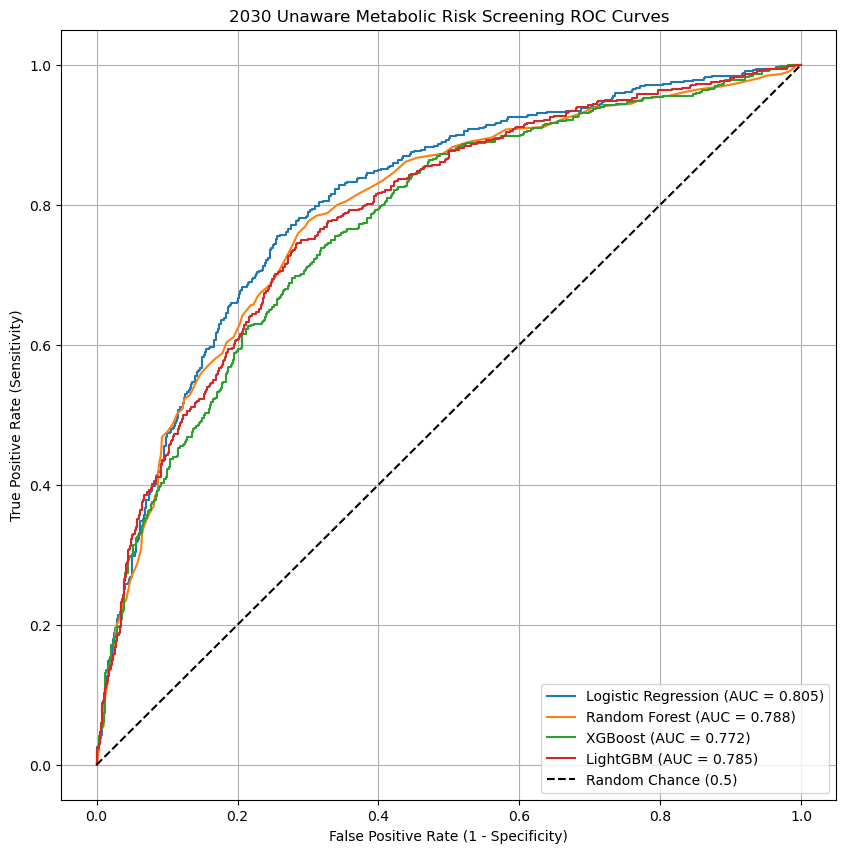

=== 모델별 최종 성능 비교표 ===
              Model  ROC-AUC   PR-AUC
Logistic Regression 0.804777 0.695022
      Random Forest 0.788339 0.673305
           LightGBM 0.785047 0.679596
            XGBoost 0.772004 0.664274


In [ ]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score

os.environ['LOKY_MAX_CPU_COUNT']=str(os.cpu_count() or 4)

# 비교 모델 4개
# 로지스틱은 의학 통계의 기준선
# 랜덤 포레스트 트리구조
# XGBoost 오차를 수정하는 그래디언트 모델
# LightGBM 분석 속도가 매우 빠름 현재 데이터분석시 가장 효율적
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1)
}

results=[]
plt.figure(figsize=(10,10))

for name,model in models.items():
    model.fit(X_train,y_train)

    y_pred_proba=model.predict_proba(X_test)[:,1]
    # predict_proba()[:,1]은 roc와 auc면적을 매끄럽게 그릴 수 있도록 확률값을 뽑아냄

    auc= roc_auc_score(y_test, y_pred_proba)
    pr_auc=average_precision_score(y_test,y_pred_proba)
    results.append({'Model': name, 'ROC-AUC': auc, 'PR-AUC': pr_auc})
    # ROC-AUC는 정상인을 정상인이라고 맞춘 확률도 포함
    # PR-AUC는 오직 환자를 환자라고 맞춘 확률만 보여줌

    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")


plt.plot([0, 1], [0, 1], 'k--', label='Random Chance (0.5)')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('2030 Unaware Metabolic Risk Screening ROC Curves')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


result_df = pd.DataFrame(results).sort_values(by='ROC-AUC', ascending=False)
print("=== 모델별 최종 성능 비교표 ===")
print(result_df.to_string(index=False))

**결과:** 이 분할과 설정에서 로지스틱 회귀의 ROC-AUC와 AP가 모두 가장 높았습니다.

| 모델 | ROC-AUC | AP(출력 이름 PR-AUC) |
|---|---:|---:|
| **로지스틱 회귀** | **0.804777** | **0.695022** |
| 랜덤 포레스트 | 0.788339 | 0.673305 |
| LightGBM | 0.785047 | 0.679596 |
| XGBoost | 0.772004 | 0.664274 |

AP 기준에서는 LightGBM이 랜덤 포레스트보다 높으므로 지표별 순위도 구분합니다. 단순한 가중합이 현재 입력에 잘 맞았을 가능성, 기본 설정의 차이, 표본 규모 등이 해석 후보가 될 수 있지만 **이 결과만으로 LR이 앞선 원인을 확인한 것은 아닙니다.**

한 번의 70:30 분할이며 차이의 신뢰구간도 없습니다. 확정할 수 있는 문장은 **‘이번 설정에서 LR이 가장 높았다’**입니다. 이후 출력들은 이 초기 학습 모델과 자료를 사용하는 설명·탐색 분석입니다.


<a id="part-3"></a>
## 3부. 초기 결과를 해석하는 법
### 3.1 LightGBM은 어떤 변수를 자주 사용했나?

아래 코드는 LightGBM이 나무를 나눌 때 각 변수를 사용한 **분할 횟수(split count)**를 보여 줍니다. 많이 쓰였다는 것은 해당 모델이 예측 규칙을 만들 때 자주 참고했다는 뜻입니다.

변수 이름 `best_model`과 달리 이 셀은 `models['LightGBM']`을 선택합니다. 앞서 가장 높은 성능을 보인 로지스틱 회귀의 설명 그래프가 아닙니다.


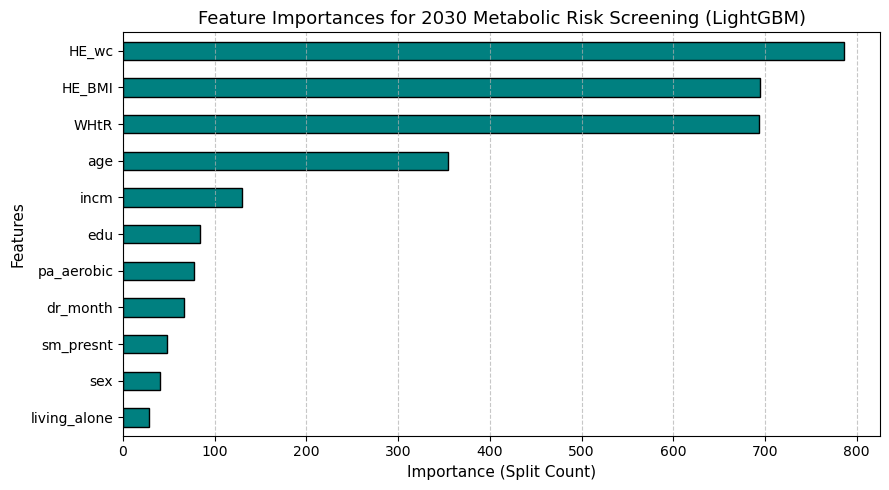

=== 변수 중요도 순위 (높은 순) ===
HE_wc           786
HE_BMI          694
WHtR            693
age             354
incm            130
edu              84
pa_aerobic       77
dr_month         66
sm_presnt        48
sex              40
living_alone     28


In [9]:
#LightGBM 모델은 트리 기반임으로 판별할때 어떤 수치를 유심히 봤나 보기 위하여 사용
best_model = models['LightGBM']
importances = pd.Series(best_model.feature_importances_, index=features).sort_values(ascending=True)
plt.figure(figsize=(9, 5))
importances.plot(kind='barh', color='teal', edgecolor='black')
plt.title('Feature Importances for 2030 Metabolic Risk Screening (LightGBM)', fontsize=13)
plt.xlabel('Importance (Split Count)', fontsize=11)
plt.ylabel('Features', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
print("=== 변수 중요도 순위 (높은 순) ===")
print(importances.sort_values(ascending=False).to_string())

**결과:** 허리둘레 **786**, BMI **694**, WHtR **693**, 나이 **354** 순으로 분할에 많이 쓰였습니다. 그 뒤는 소득 130, 교육 84, 운동 77, 음주 66, 흡연 48, 성별 40, 1인 가구 28입니다.

**해석:** 이 모델에서 체형 정보가 자주 사용되었습니다. 다만 연속값은 나눌 지점이 많고 0/1 변수는 적으므로 분할 횟수는 변수 형식의 영향도 받습니다. 비슷한 정보를 담은 변수들 사이에서 사용량이 분산될 수도 있습니다. 이 값은 위험을 올리거나 내리는 방향, 변수의 인과 효과, EPF 내부 상태의 의미를 알려 주지 않습니다.


### 3.2 Table 1: 두 집단은 어떻게 다른가?

**질문:** 모델 성능과 별개로, Target=0과 Target=1의 표본 특성은 어떤가?

아래 셀은 최종 분석 자료 전체에서 두 집단을 비교합니다. 연속값은 **평균 ± 표준편차**와 Welch t-검정, 범주는 비율과 카이제곱 검정을 사용합니다. 표준편차는 사람들의 값이 평균 주변에 얼마나 퍼져 있는지 나타냅니다.

p값은 ‘집단 차이가 없다는 가정과 검정 조건 아래에서 관측값 이상으로 극단적인 결과가 나올 정도’를 뜻합니다. 효과 크기나 원인일 확률이 아닙니다. 여러 항목을 동시에 살펴보고 조사 설계를 반영하지 않은 탐색표라는 점도 함께 읽습니다.


In [10]:
from scipy import stats

# 비교할 주요 변수들 정의 (연속형 변수와 범주형 변수)
cont_vars = ['age', 'HE_ht', 'HE_wt', 'HE_BMI', 'HE_wc', 'WHtR', 'HE_glu', 'HE_sbp', 'HE_dbp', 'HE_TG', 'HE_HDL_st2']
cat_vars = ['sex', 'incm', 'sm_presnt', 'dr_month', 'pa_aerobic','living_alone']

table1_rows = []

# 연속형 변수 t-test 및 Mean ± SD 계산
for var in cont_vars:
    g0 = data_clean[data_clean['Target'] == 0][var].dropna()
    g1 = data_clean[data_clean['Target'] == 1][var].dropna()
    
    # 두 집단 독립표본 t-검정
    stat, pval = stats.ttest_ind(g0, g1, equal_var=False)
    p_str = "< 0.001" if pval < 0.001 else f"{pval:.3f}"
    
    table1_rows.append({
        'Variable': var,
        'Normal Group (Target=0)': f"{g0.mean():.1f} ± {g0.std():.1f}",
        'Risk Group (Target=1)': f"{g1.mean():.1f} ± {g1.std():.1f}",
        'p-value': p_str
    })

for var in cat_vars:
    ct = pd.crosstab(data_clean[var], data_clean['Target'])
    chi2, pval, _, _ = stats.chi2_contingency(ct)
    p_str = "< 0.001" if pval < 0.001 else f"{pval:.3f}"
    
    # 1인 비율(예: 남성 비율, 흡연율, 음주율 등)
    pct0 = (data_clean[data_clean['Target'] == 0][var] == 1).mean() * 100
    pct1 = (data_clean[data_clean['Target'] == 1][var] == 1).mean() * 100
    
    table1_rows.append({
        'Variable': f"{var} (Yes %)",
        'Normal Group (Target=0)': f"{pct0:.1f}%",
        'Risk Group (Target=1)': f"{pct1:.1f}%",
        'p-value': p_str
    })

table1_df = pd.DataFrame(table1_rows)
print("=== Table 1: Baseline Characteristics of Study Population ===")
table1_df

=== Table 1: Baseline Characteristics of Study Population ===


,Variable,Normal Group (Target=0),Risk Group (Target=1),p-value
0,age,28.6 ± 5.9,30.7 ± 5.8,< 0.001
1,HE_ht,167.0 ± 8.3,169.8 ± 8.7,< 0.001
2,HE_wt,62.3 ± 12.8,76.0 ± 16.4,< 0.001
3,HE_BMI,22.2 ± 3.5,26.2 ± 4.7,< 0.001
4,HE_wc,75.6 ± 9.8,87.9 ± 12.2,< 0.001
5,WHtR,0.5 ± 0.1,0.5 ± 0.1,< 0.001
6,HE_glu,88.5 ± 5.8,97.8 ± 20.8,< 0.001
7,HE_sbp,108.1 ± 9.3,117.8 ± 13.0,< 0.001
8,HE_dbp,68.0 ± 6.6,75.3 ± 10.1,< 0.001
9,HE_TG,76.8 ± 27.4,166.3 ± 118.5,< 0.001


**결과:** 위험군의 나이는 **30.7 vs 28.6세**, 허리둘레는 **87.9 vs 75.6cm**, BMI는 **26.2 vs 22.2**였습니다. 남성 비율은 **59.4% vs 37.3%**, 흡연율은 **23.4% vs 12.6%**였습니다(위험군 vs Target=0).

월간 음주의 p값은 0.497, 운동은 0.036, 1인 가구는 0.069입니다. 이 수치만으로 비유의 항목이 무관하다고 결론 내리지 않습니다.

| 표에서 헷갈리기 쉬운 부분 | 읽는 방법 |
|---|---|
| 혈당·혈압·TG·HDL의 큰 차이 | Target을 만든 검사값이므로, 집단 차이 자체가 새로운 예측 발견은 아님 |
| `sex (Yes %)` / `incm (Yes %)` | 각각 남성 비율 / 소득 하위 25%(1분위) 비율. 소득 p값은 네 수준 전체 비교 |
| WHtR가 모두 0.5로 표시 | 소수 첫째 자리 반올림으로 차이가 가려질 수 있음 |
| 교육수준 | 입력에는 있지만 이 Table 1에는 없음 |
| 치우친 TG 분포 | 평균·표준편차와 함께 중앙값·사분위범위를 보면 좋음 |
| 한국 청년 전체로의 해석 | 조사 가중치를 적용하지 않은 표본 수치임 |

원본 정리자의 추가 메모에는 WHtR **0.453±0.053 vs 0.517±0.066**, TG 중앙값(사분위범위) **72(56–94) vs 148.5(96–195)**가 있습니다(Target=0 vs 위험군). 이 상세 재집계는 이번 편집에서 검증하지 않은 원본 기록입니다.


### 3.3 확률을 실제 판정으로 바꾸면?

**질문:** 위험 확률이 얼마 이상이면 추가 검사를 고려할 사람으로 분류할까?

기준을 낮추면 더 많은 위험군을 찾지만 정상인도 더 많이 걸립니다. **Youden 지수**는 두 측면을 같은 무게로 합칩니다.

$$J=\text{민감도}+\text{특이도}-1.$$

아래 코드는 로지스틱 회귀의 시험 예측에서 $J$가 가장 큰 기준을 고르고, 실제 상태와 판정을 교차한 **혼동행렬**을 만듭니다. 이 셀은 **시험 자료로 기준을 고른 뒤 같은 자료에서 평가**하므로, 여기의 민감도·특이도는 독립적으로 확정된 선별 성능보다 낙관적일 수 있습니다.


수학적 최적의 위험 판정 기준치(Threshold): 0.363
모델의 민감도(Sensitivity, 질환 포착률) : 75.5%
모델의 특이도(Specificity, 정상 감별률) : 74.4%



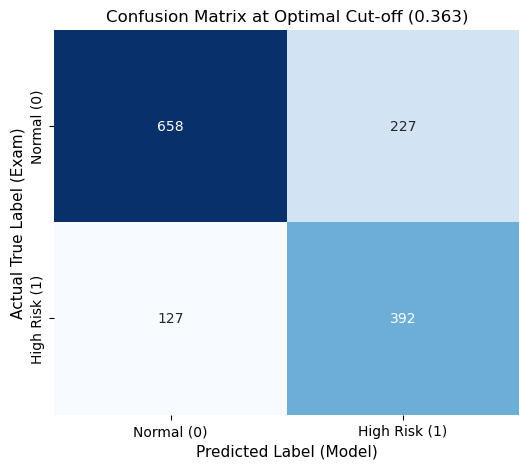

=== 상세 분류 성능 보고서 ===
              precision    recall  f1-score   support

      Normal       0.84      0.74      0.79       885
   High Risk       0.63      0.76      0.69       519

    accuracy                           0.75      1404
   macro avg       0.74      0.75      0.74      1404
weighted avg       0.76      0.75      0.75      1404



In [11]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 로지스틱 회귀의 시험 데이터 예측 확률 가져오기
lr_model = models['Logistic Regression']
y_proba = lr_model.predict_proba(X_test)[:, 1]

# 유덴지수로 수학적 최적의 임계치 계산
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
youden_j = tpr - fpr
opt_idx = np.argmax(youden_j)
opt_threshold = thresholds[opt_idx]

# 최적 기준치를 적용한 예측값 결정 (0 또는 1)
y_pred_opt = (y_proba >= opt_threshold).astype(int)

# 혼동행렬(Confusion Matrix) 계산
cm = confusion_matrix(y_test, y_pred_opt)
tn, fp, fn, tp = cm.ravel()
# ravel함수는 1차원 평면으로 펼쳐서 변수에 넣음

sensitivity = tp / (tp + fn)  # 민감도 (진짜 위험군을 맞힌 비율)
specificity = tn / (tn + fp)  # 특이도 (정상인을 정상으로 맞힌 비율)

print(f"수학적 최적의 위험 판정 기준치(Threshold): {opt_threshold:.3f}")
print(f"모델의 민감도(Sensitivity, 질환 포착률) : {sensitivity * 100:.1f}%")
print(f"모델의 특이도(Specificity, 정상 감별률) : {specificity * 100:.1f}%\n")


plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar=False,
            xticklabels=['Normal (0)', 'High Risk (1)'],
            yticklabels=['Normal (0)', 'High Risk (1)'])
plt.title(f'Confusion Matrix at Optimal Cut-off ({opt_threshold:.3f})', fontsize=12)
plt.xlabel('Predicted Label (Model)', fontsize=11)
plt.ylabel('Actual True Label (Exam)', fontsize=11)
plt.show()

print("=== 상세 분류 성능 보고서 ===")
print(classification_report(y_test, y_pred_opt, target_names=['Normal', 'High Risk']))

**결과:** 선택된 기준은 약 **0.363**입니다. 저장된 그림의 네 칸은 다음과 같습니다.

| 실제 상태 \ 모델 판정 | 정상 | 위험 | 합계 |
|---|---:|---:|---:|
| Target=0 | 658 | 227(헛경보) | 885 |
| Target=1 | 127(놓침) | 392 | 519 |

| 지표 | 계산 | 결과 |
|---|---|---:|
| 민감도 | 392 / 519 | **75.5%** |
| 특이도 | 658 / 885 | **74.4%** |
| 정밀도(양성 예측도) | 392 / 619 | 63.3% |
| 음성 예측도 | 658 / 785 | 83.8% |
| 위험 판정 비율 | 619 / 1,404 | 44.1% |

**해석:** 이 기준에서는 위험군 약 네 명 중 세 명을 찾고 127명은 놓쳤습니다. ‘수학적 최적’은 **Youden 지수에 대한 최적**입니다. 실제 선별에서는 놓침·추가 검사의 비용과 목적을 정해야 하며, 기준은 학습 내부 자료에서 고른 뒤 별도 시험 자료에 적용해야 합니다. 이 표가 곧바로 사용할 임상 기준을 확정하지는 않습니다.


### 3.4 Table 2: 오즈비로 관련성 읽기

**질문:** 여러 입력을 함께 넣었을 때 각 항목은 Target과 어떤 방향으로 관련되는가?

**오즈**는 확률 $p$를 $p/(1-p)$로 바꾼 값입니다. **오즈비(OR)**는 두 조건의 오즈를 나눈 비율이고, 로지스틱 계수에서 $e^\beta$로 얻습니다. 확률 자체의 비인 위험비와는 다릅니다. 예를 들어 기준 확률이 20%라면 OR=1.5는 오즈 0.25→0.375, 확률 약 **27.3%**에 해당합니다. ‘확률이 1.5배’와 같지 않습니다.

아래 코드는 WHtR를 뺀 **10개 변수**로 학습 자료 3,276명에 로지스틱 회귀를 다시 맞춥니다. 나머지 변수를 고정한 계수의 조건부 해석을 **조정 오즈비(aOR)**라고 부릅니다. 표준오차는 $p(1-p)$로 가중한 정보 행렬의 역행렬로 근사합니다.

원본 주석의 ‘통계적 인과 분석’은 실제 분석 범위를 넘는 표현입니다. 이 표는 **횡단면 자료의 조정된 연관성**이며 인과·매개 분석이 아닙니다. 또한 L2 규제로 적합한 계수에 비규제 모형의 표준오차 공식을 적용하므로 구간과 p값은 방법상 한계를 가진 근사치입니다.


In [12]:
analysis_features = [f for f in features if f != 'WHtR']

# 통계적 인과 분석을 위한 로지스틱 회귀 모델 학습
X_train_stat = X_train[analysis_features]
lr_stat = LogisticRegression(max_iter=1000, random_state=42)
lr_stat.fit(X_train_stat, y_train)


# 로지스틱 회귀 계수(Beta)와 오즈비(Odds Ratio = exp(Beta)) 계산
coef = lr_stat.coef_[0]
odds_ratios = np.exp(coef)

# 2. 통계적 95% 신뢰구간 근사 계산 (Standard Error 추정)
# 디자인 행렬 X에 절편(상수항) 추가
X_mat = np.hstack([np.ones((X_train_stat.shape[0], 1)), X_train_stat.values])
p_train = lr_stat.predict_proba(X_train_stat)[:, 1]
V = p_train * (1 - p_train)
cov = np.linalg.inv(np.dot(X_mat.T, X_mat * V[:, np.newaxis]))
se = np.sqrt(np.diag(cov))[1:]  # 각 독립변수별 표준오차

# 95% 신뢰구간 (CI) 및 z-score, p-value 계산
ci_lower = np.exp(coef - 1.96 * se)
ci_upper = np.exp(coef + 1.96 * se)
z_scores = coef / se
p_values = 2 * (1 - stats.norm.cdf(np.abs(z_scores)))


or_df = pd.DataFrame({
    'Variable': analysis_features,
    'Beta (계수)': coef.round(3),
    'Odds Ratio (aOR)': odds_ratios.round(3),
    '95% CI (하한 ~ 상한)': [f"{l:.3f} ~ {u:.3f}" for l, u in zip(ci_lower, ci_upper)],
    'p-value': ["< 0.001" if p < 0.001 else f"{p:.3f}" for p in p_values]
}).sort_values(by='Odds Ratio (aOR)', ascending=False)

print("=== Table 2: Multivariate Adjusted Odds Ratios (aOR) ===")
print(or_df.to_string(index=False))

=== Table 2: Multivariate Adjusted Odds Ratios (aOR) ===
    Variable  Beta (계수)  Odds Ratio (aOR) 95% CI (하한 ~ 상한) p-value
   sm_presnt      0.407             1.502    1.200 ~ 1.881 < 0.001
         sex      0.102             1.108    0.889 ~ 1.380   0.361
       HE_wc      0.102             1.107    1.083 ~ 1.132 < 0.001
         age      0.045             1.046    1.029 ~ 1.062 < 0.001
      HE_BMI     -0.001             0.999    0.947 ~ 1.055   0.979
        incm     -0.075             0.928    0.858 ~ 1.003   0.061
  pa_aerobic     -0.124             0.883    0.742 ~ 1.050   0.160
    dr_month     -0.152             0.859    0.720 ~ 1.025   0.091
         edu     -0.180             0.835    0.703 ~ 0.992   0.040
living_alone     -0.276             0.759    0.598 ~ 0.962   0.023


**결과:** 원본의 근사 구간과 함께 주요 값을 읽습니다.

| 변수 | aOR (근사 95% CI) | 이 모형 안의 해석 |
|---|---|---|
| 현재 흡연 | **1.502 (1.200–1.881)** | 비흡연 대비 위험군 오즈가 약 1.5배 |
| 허리둘레 | **1.107 (1.083–1.132)** / cm | 1cm 증가에 오즈 약 10.7% 증가 |
| 나이 | **1.046 (1.029–1.062)** / 세 | 1세 증가에 오즈 약 4.6% 증가 |
| 교육수준 | 0.835 (0.703–0.992) / 단계 | 단계 증가와 낮은 오즈가 관련 |
| 1인 가구 | 0.759 (0.598–0.962) | 이 조정 모형에서는 낮은 오즈가 관측 |
| 성별·BMI·소득·운동·음주 | 구간이 1을 포함 | 현재 모형과 근사 구간에서 명확한 방향이 확인되지 않음 |

1cm 효과가 같은 로그오즈 간격으로 이어진다는 모형 가정 아래 허리둘레 10cm의 OR는 약 $1.107^{10}\approx2.8$입니다. 나이 10세는 약 $1.046^{10}\approx1.6$입니다. 단위가 다른 항목의 OR 크기를 그대로 비교해 중요도 순위로 삼지 않습니다.

BMI와 허리둘레의 정보 중복은 계수 해석에 영향을 줄 수 있지만, 이 계수표만으로 공선성의 크기나 BMI의 전체 기여를 확정하지 못합니다. 성별의 비유의 계수도 ‘성별 차이 대부분이 체형 때문에 생겼다’는 분해 증거가 아닙니다. 소득·교육은 1–4를 숫자로 넣은 동일 단계 효과 가정에 따른 값입니다.


### 3.5 Forest plot: 오즈비와 구간을 함께 보기

아래 그림은 바로 앞 Table 2를 시각화합니다. **점은 aOR, 가로선은 근사 95% 구간, 세로 점선은 OR=1**입니다. 오른쪽은 높은 오즈, 왼쪽은 낮은 오즈와 관련된 방향이며 ‘위험을 일으킴/예방함’의 인과 방향은 아닙니다.

흡연·허리둘레·나이는 오른쪽, 교육·1인 가구는 왼쪽에 있고 나머지 구간은 1을 가로지릅니다. 허리둘레 선이 짧게 보이는 것은 **1cm라는 단위와 표시 축**의 영향도 받습니다. 앞의 규제·표준오차 불일치까지 고려해야 하므로 선 길이만으로 가장 정밀한 원인 추정이라고 읽지 않습니다. 가로축은 0.4–2.5로 고정되어 있습니다.


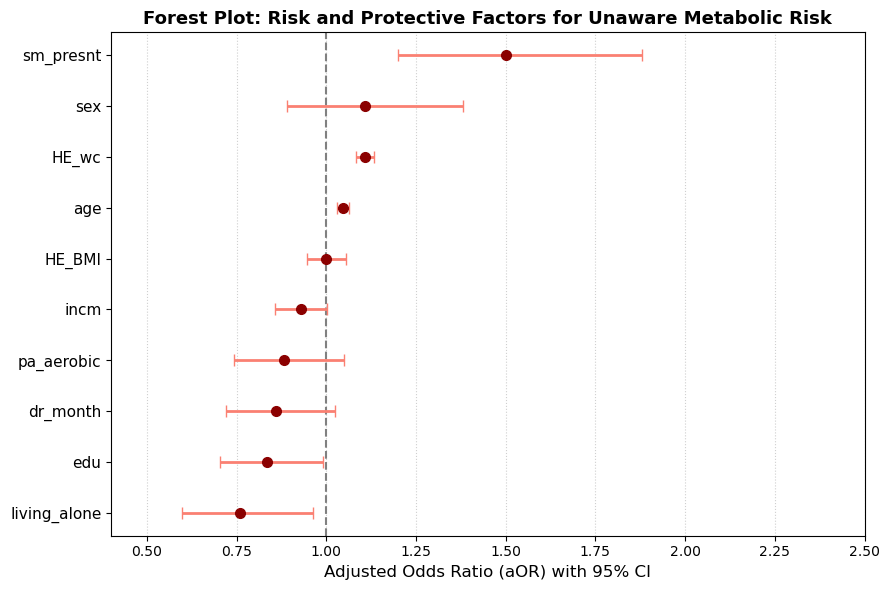

In [13]:
# 정렬된 오즈비 데이터 준비 (상수항 제외)
plot_df = or_df.sort_values(by='Odds Ratio (aOR)', ascending=True).copy()

plt.figure(figsize=(9, 6))

# 기준선 1.0 그리기 (1.0보다 크면 위험 요인, 작으면 보호 요인)
plt.axvline(x=1.0, color='gray', linestyle='--', linewidth=1.5, label='Baseline (OR = 1.0)')


y_pos = range(len(plot_df))
ci_lowers = [float(ci.split(' ~ ')[0]) for ci in plot_df['95% CI (하한 ~ 상한)']]
ci_uppers = [float(ci.split(' ~ ')[1]) for ci in plot_df['95% CI (하한 ~ 상한)']]
errors = [
    plot_df['Odds Ratio (aOR)'] - ci_lowers,
    ci_uppers - plot_df['Odds Ratio (aOR)']
]

plt.errorbar(plot_df['Odds Ratio (aOR)'], y_pos, xerr=errors, fmt='o', 
             color='darkred', ecolor='salmon', elinewidth=2, capsize=4, markersize=7)

plt.yticks(y_pos, plot_df['Variable'], fontsize=11)
plt.xlim(0.4, 2.5)  # 직관적 비교를 위한 범위 설정
plt.xlabel('Adjusted Odds Ratio (aOR) with 95% CI', fontsize=12)
plt.title('Forest Plot: Risk and Protective Factors for Unaware Metabolic Risk', fontsize=13, fontweight='bold')
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### 3.6 성별·연령대별로 나누어 보면?

**질문:** 전체 평균 뒤에 어떤 집단별 차이가 있는가?

아래 셀은 ① 성별×연령대의 Target 비율, ② 19–29세와 30–39세별 로지스틱 AUC, ③ 네 성별·연령 그룹의 흡연 aOR를 만듭니다. 원본의 ‘20대’ 표시는 **19세도 포함한 19–29세**입니다.

이 셀의 연령대별 모델은 **학습한 자료를 그대로 평가**합니다. 전체 분석의 시험 AUC와 다른 종류의 값입니다. 각 모델에는 나이 변수가 들어 있지 않으며, 집단별 흡연 계수에는 신뢰구간이 없습니다.


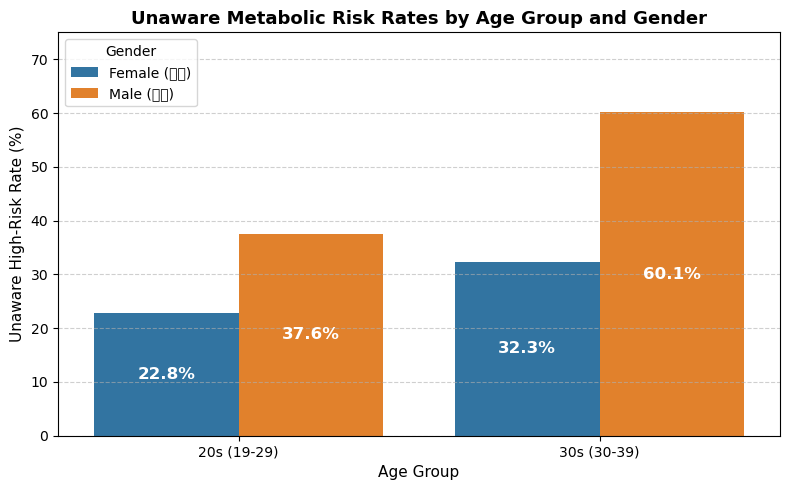

20대 전체 모델 판별력(ROC-AUC): 0.779
30대 전체 모델 판별력(ROC-AUC): 0.808

=== [세부 분석] 성별 및 연령대별 4개 세부 그룹의 흡연 위험도(aOR) 비교 ===
         성별         연령대  표본수(N)  흡연 Beta(계수)  조정 오즈비(aOR)
  Male (남성) 20s (19-29)    1118        0.194        1.215
  Male (남성) 30s (30-39)    1010        0.552        1.737
Female (여성) 20s (19-29)    1278        0.557        1.745
Female (여성) 30s (30-39)    1274        0.341        1.406


In [14]:
# 1. 20대(19~29세)와 30대(30~39세) 그룹 분할 및 성별 라벨링
data_clean['age_group'] = np.where(data_clean['age'] < 30, '20s (19-29)', '30s (30-39)')
data_clean['gender'] = np.where(data_clean['sex'] == 1, 'Male (남성)', 'Female (여성)')

# 2. 성별 x 연령대별 미인지 대사이상 위험군 비율(%) 계산 및 막대그래프 시각화
sub_stats = data_clean.groupby(['gender', 'age_group'])['Target'].agg(['count', 'mean']).reset_index()
sub_stats['Risk_Pct'] = sub_stats['mean'] * 100

plt.figure(figsize=(8, 5))
bar_plot = sns.barplot(data=sub_stats, x='age_group', y='Risk_Pct', hue='gender', palette=['#1f77b4', '#ff7f0e'])

for p in bar_plot.patches:
    height = p.get_height()
    if height > 0:
        bar_plot.annotate(f'{height:.1f}%', 
                          (p.get_x() + p.get_width() / 2., height / 2),
                          ha='center', va='center', fontsize=12, color='white', fontweight='bold')

plt.title('Unaware Metabolic Risk Rates by Age Group and Gender', fontsize=13, fontweight='bold')
plt.xlabel('Age Group', fontsize=11)
plt.ylabel('Unaware High-Risk Rate (%)', fontsize=11)
plt.ylim(0, 75)
plt.legend(title='Gender', loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 3. 20대 코호트 vs 30대 코호트 독립 학습 및 판별력(ROC-AUC) 비교
d20 = data_clean[data_clean['age'] < 30]
d30 = data_clean[data_clean['age'] >= 30]
sub_feats = ['incm', 'edu', 'HE_BMI', 'HE_wc', 'sm_presnt', 'dr_month', 'pa_aerobic', 'living_alone']

m20 = LogisticRegression(max_iter=1000, random_state=42).fit(d20[sub_feats + ['sex']], d20['Target'])
m30 = LogisticRegression(max_iter=1000, random_state=42).fit(d30[sub_feats + ['sex']], d30['Target'])

auc20 = roc_auc_score(d20['Target'], m20.predict_proba(d20[sub_feats + ['sex']])[:, 1])
auc30 = roc_auc_score(d30['Target'], m30.predict_proba(d30[sub_feats + ['sex']])[:, 1])

print(f"20대 전체 모델 판별력(ROC-AUC): {auc20:.3f}")
print(f"30대 전체 모델 판별력(ROC-AUC): {auc30:.3f}\n")

# 4.성별 x 연령대별 4개 세부 그룹의 흡연 위험 가중치(Beta 및 aOR) 비교
group_results = []
for g_name, g_val in [('Male (남성)', 1), ('Female (여성)', 2)]:
    for a_name, a_cond in [('20s (19-29)', data_clean['age'] < 30), ('30s (30-39)', data_clean['age'] >= 30)]:
        sub = data_clean[(data_clean['sex'] == g_val) & a_cond]
        m_sub = LogisticRegression(max_iter=1000, random_state=42).fit(sub[sub_feats], sub['Target'])
        sm_idx = sub_feats.index('sm_presnt')
        beta = m_sub.coef_[0][sm_idx]
        aor = np.exp(beta)
        group_results.append({
            '성별': g_name,
            '연령대': a_name,
            '표본수(N)': len(sub),
            '흡연 Beta(계수)': round(beta, 3),
            '조정 오즈비(aOR)': round(aor, 3)
        })

smoke_df = pd.DataFrame(group_results)
print("=== [세부 분석] 성별 및 연령대별 4개 세부 그룹의 흡연 위험도(aOR) 비교 ===")
print(smoke_df.to_string(index=False))

**결과:** 저장된 집단별 비율과 흡연 aOR는 다음과 같습니다.

| 그룹 | 표본 수 | Target=1 비율 | 흡연 aOR |
|---|---:|---:|---:|
| 남성 19–29세 | 1,118 | 37.6% | 1.215 |
| 남성 30–39세 | 1,010 | **60.1%** | 1.737 |
| 여성 19–29세 | 1,278 | 22.8% | 1.745 |
| 여성 30–39세 | 1,274 | 32.3% | 1.406 |

19–29세 모델 AUC는 **0.779**, 30–39세는 **0.808**이지만 둘 다 학습 자료에서의 값입니다. 새로운 사람에게 30대 모델이 더 좋다고 입증한 결과는 아닙니다. 흡연 aOR 차이도 구간과 상호작용 검정 없이 집단별 효과 차이로 확정할 수 없습니다.

이 표는 초기 코호트의 탐색 결과입니다. 후속 EPF의 하위집단 성능표로 옮겨 읽지 않습니다. 저장된 일부 초기 그림의 한글 글꼴 문제는 마지막 실행 안내에서 다룹니다.


### 3.7 1인 가구와 다인 가구의 차이

**질문:** 혼자 사는 청년의 흡연율과 대사이상 지표는 어떻게 보이는가?

아래 셀은 `cfam==1`인 1인 가구와 나머지를 비교합니다. 원본 출력의 `Solo (자취)`와 `Family (동거)`는 편의상 붙인 라벨입니다. 실제 변수는 가구원 수이므로 **자취 여부·가족 관계를 직접 구분한 조사로 확대하지 않습니다.**

그림 A는 성별×가구 형태의 흡연율, B는 30–39세의 혈압 상승·TG 상승·복부비만 비율입니다. 이어지는 표는 연령·성별로 더 나눕니다. 복부비만은 이 셀에서 남성 허리둘레 ≥90cm, 여성 ≥85cm로 정의한 별도 지표이며 초기 Target의 구성요소에는 넣지 않았습니다.


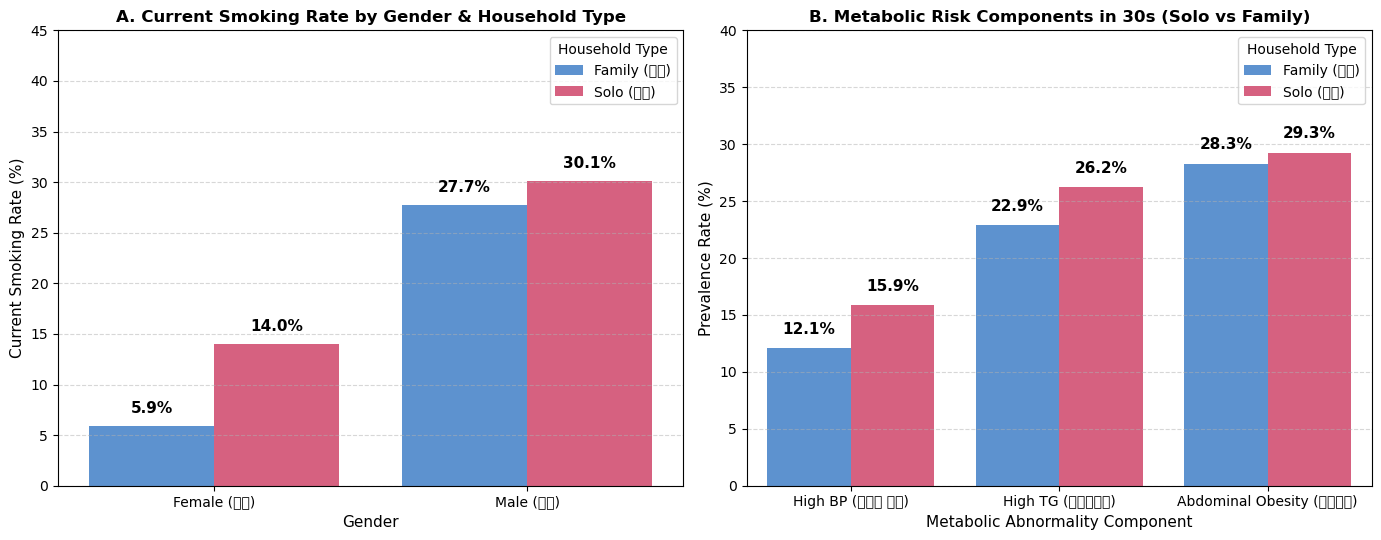

=== 청년 1인 가구(자취) 건강 행태 및 대사위험 통계 요약 ===
1. [핵심 매개 원인] 여성 자취 청년 흡연율: 14.0% vs 가족동거: 5.9% (카이제곱 p-value: 1.70e-07)
2. [대사이상 전체] 30대 자취 청년 고혈압 위험: 15.9% vs 가족동거: 12.1%
3. [대사이상 전체] 30대 자취 청년 고중성지방 위험: 26.2% vs 가족동거: 22.9%

=== [세부 분석 1] 20대 성별 x 가구형태별 대사위험 지표 ===
                         표본수(N)  고혈압 위험(%)  고중성지방(%)  복부비만(%)
gender      household                                        
Female (여성) Family (동거)    1080        1.8       7.6     10.2
            Solo (자취)       198        2.0       7.1      9.1
Male (남성)   Family (동거)     890       14.0      21.3     28.8
            Solo (자취)       228        9.6      15.4     27.2

=== [세부 분석 2] 30대 성별 x 가구형태별 대사위험 지표 ===
                         표본수(N)  고혈압 위험(%)  고중성지방(%)  복부비만(%)
gender      household                                        
Female (여성) Family (동거)    1143        5.8      11.7     19.2
            Solo (자취)       131        5.3      11.5     18.3
Male (남성)   Family (동거)     813       20.9      38.6     41.1
            Sol

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats

# 1. 가구 형태 및 라벨링
data_clean['household'] = np.where(data_clean['living_alone'] == 1, 'Solo (자취)', 'Family (동거)')
data_clean['gender'] = np.where(data_clean['sex'] == 1, 'Male (남성)', 'Female (여성)')
data_clean['age_group'] = np.where(data_clean['age'] < 30, '20s (19-29)', '30s (30-39)')

# 2. 대사위험 세부 지표 정의 (혈압, 중성지방, 복부비만)
data_clean['high_bp'] = np.where((data_clean['HE_sbp'] >= 130) | (data_clean['HE_dbp'] >= 85), 1, 0)
data_clean['high_tg'] = np.where(data_clean['HE_TG'] >= 150, 1, 0)
data_clean['ab_obesity'] = np.where(
    ((data_clean['sex'] == 1) & (data_clean['HE_wc'] >= 90)) | 
    ((data_clean['sex'] == 2) & (data_clean['HE_wc'] >= 85)), 1, 0
)

# 3. 2분할 시각화 차트 (Figure 4: Panel A - 성별 흡연율 격차 / Panel B - 30대 대사이상 지표 격차)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# [Panel A] 성별 x 가구형태별 현재 흡연율 비교 (1등 생활습관 위험 인자의 격차)
sm_stats = data_clean.groupby(['gender', 'household'])['sm_presnt'].agg(['count', 'mean']).reset_index()
sm_stats['Smoking_Pct'] = sm_stats['mean'] * 100

bar_a = sns.barplot(data=sm_stats, x='gender', y='Smoking_Pct', hue='household', 
                    palette=['#4a90e2', '#e94e77'], ax=axes[0])
axes[0].set_title('A. Current Smoking Rate by Gender & Household Type', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Gender', fontsize=11)
axes[0].set_ylabel('Current Smoking Rate (%)', fontsize=11)
axes[0].set_ylim(0, 45)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
axes[0].legend(title='Household Type', loc='upper right')

for p in bar_a.patches:
    h = p.get_height()
    if h > 0:
        bar_a.annotate(f'{h:.1f}%', (p.get_x() + p.get_width() / 2., h + 1),
                       ha='center', va='bottom', fontsize=11, fontweight='bold')

# [Panel B] 30대 청년의 가구형태별 주요 대사이상 3대 지표 유병률 비교 (대사질환 결과)
d30 = data_clean[data_clean['age_group'] == '30s (30-39)']
mets_comp = pd.DataFrame({
    'Condition': [
        'High BP (고혈압 위험)', 'High BP (고혈압 위험)',
        'High TG (고중성지방)', 'High TG (고중성지방)',
        'Abdominal Obesity (복부비만)', 'Abdominal Obesity (복부비만)'
    ],
    'Household': [
        'Family (동거)', 'Solo (자취)',
        'Family (동거)', 'Solo (자취)',
        'Family (동거)', 'Solo (자취)'
    ],
    'Rate (%)': [
        d30[d30['living_alone'] == 0]['high_bp'].mean() * 100,
        d30[d30['living_alone'] == 1]['high_bp'].mean() * 100,
        d30[d30['living_alone'] == 0]['high_tg'].mean() * 100,
        d30[d30['living_alone'] == 1]['high_tg'].mean() * 100,
        d30[d30['living_alone'] == 0]['ab_obesity'].mean() * 100,
        d30[d30['living_alone'] == 1]['ab_obesity'].mean() * 100
    ]
})

bar_b = sns.barplot(data=mets_comp, x='Condition', y='Rate (%)', hue='Household',
                    palette=['#4a90e2', '#e94e77'], ax=axes[1])
axes[1].set_title('B. Metabolic Risk Components in 30s (Solo vs Family)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Metabolic Abnormality Component', fontsize=11)
axes[1].set_ylabel('Prevalence Rate (%)', fontsize=11)
axes[1].set_ylim(0, 40)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
axes[1].legend(title='Household Type', loc='upper right')

for p in bar_b.patches:
    h = p.get_height()
    if h > 0:
        bar_b.annotate(f'{h:.1f}%', (p.get_x() + p.get_width() / 2., h + 1),
                       ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# 4. 통계적 유의성 검정 및 요약 출력
f_df = data_clean[data_clean['sex'] == 2]
ct_f_sm = pd.crosstab(f_df['living_alone'], f_df['sm_presnt'])
_, p_f_sm, _, _ = stats.chi2_contingency(ct_f_sm)

print("=== 청년 1인 가구(자취) 건강 행태 및 대사위험 통계 요약 ===")
print(f"1. [핵심 매개 원인] 여성 자취 청년 흡연율: {f_df[f_df['living_alone']==1]['sm_presnt'].mean()*100:.1f}% vs 가족동거: {f_df[f_df['living_alone']==0]['sm_presnt'].mean()*100:.1f}% (카이제곱 p-value: {p_f_sm:.2e})")
print(f"2. [대사이상 전체] 30대 자취 청년 고혈압 위험: {d30[d30['living_alone']==1]['high_bp'].mean()*100:.1f}% vs 가족동거: {d30[d30['living_alone']==0]['high_bp'].mean()*100:.1f}%")
print(f"3. [대사이상 전체] 30대 자취 청년 고중성지방 위험: {d30[d30['living_alone']==1]['high_tg'].mean()*100:.1f}% vs 가족동거: {d30[d30['living_alone']==0]['high_tg'].mean()*100:.1f}%\n")

# 5. [세부 분석] 20대 및 30대 성별 x 가구형태별 대사위험 3대 지표 비교
d20 = data_clean[data_clean['age_group'] == '20s (19-29)']
d30 = data_clean[data_clean['age_group'] == '30s (30-39)']

# 20대 세부 요약표
sub_20_stats = d20.groupby(['gender', 'household'])[['high_bp', 'high_tg', 'ab_obesity']].mean() * 100
sub_20_counts = d20.groupby(['gender', 'household'])['ID'].count()
summary_20 = pd.concat([sub_20_counts.rename('표본수(N)'), sub_20_stats.round(1).rename(columns={
    'high_bp': '고혈압 위험(%)',
    'high_tg': '고중성지방(%)',
    'ab_obesity': '복부비만(%)'
})], axis=1)

# 30대 세부 요약표
sub_30_stats = d30.groupby(['gender', 'household'])[['high_bp', 'high_tg', 'ab_obesity']].mean() * 100
sub_30_counts = d30.groupby(['gender', 'household'])['ID'].count()
summary_30 = pd.concat([sub_30_counts.rename('표본수(N)'), sub_30_stats.round(1).rename(columns={
    'high_bp': '고혈압 위험(%)',
    'high_tg': '고중성지방(%)',
    'ab_obesity': '복부비만(%)'
})], axis=1)

print("=== [세부 분석 1] 20대 성별 x 가구형태별 대사위험 지표 ===")
print(summary_20.to_string())
print("\n=== [세부 분석 2] 30대 성별 x 가구형태별 대사위험 지표 ===")
print(summary_30.to_string())

**결과:** 여성 1인 가구의 흡연율은 **14.0%**, 다인 가구 여성은 **5.9%**였습니다(카이제곱 p=1.70×10⁻⁷). 남성은 각각 **30.1% vs 27.7%**였습니다. 30대 전체에서는 1인 가구의 혈압 상승 **15.9% vs 12.1%**, TG 상승 **26.2% vs 22.9%**, 복부비만 **29.3% vs 28.3%**가 관측됐습니다.

그러나 30대 1인 가구는 남성 비율이 **60.1%(197/328)**이고 다인 가구는 **41.6%(813/1,956)**입니다. 성별로 나누면 전체와 다른 패턴이 보입니다.

| 30대: 다인 가구 → 1인 가구 | 혈압 상승 | TG 상승 | 복부비만 |
|---|---:|---:|---:|
| 남성 | 20.9 → 22.8% | 38.6 → 36.0% | 41.1 → 36.5% |
| 여성 | 5.8 → 5.3% | 11.7 → 11.5% | 19.2 → 18.3% |

**해석:** 집단 구성의 차이가 전체 비교에 영향을 줄 가능성을 보여 줍니다. 성별로 나눈 관측표만으로 그 영향을 인과적으로 분해하거나 ‘심슨 역설이 원인’이라고 확정한 것은 아닙니다. 30대 지표 비교에는 통계 검정도 없습니다.

확인한 것은 여성 1인 가구의 높은 표본 흡연율과 집단별 분포입니다. 출력의 **‘핵심 매개 원인’은 과도한 표현**이며, 1인 가구→흡연→대사이상의 경로를 검증한 매개분석은 수행하지 않았습니다. 이 결과로 혼자 사는 행위의 건강 효과를 단정하지 않습니다.


### 초기 분석에서 다음 연구로 넘어가기

초기 분석은 간단한 11개 정보로 **네 소견 중 하나 이상**을 예측하고, 그 표본의 관련 요인을 살펴본 출발점입니다. 가장 높은 관측 성능은 LR이었고, 체형·흡연·나이와 Target의 연관이 보였습니다. 대상 정의·검사값 결측·시험 자료에서 선택한 기준 등의 해석 범위는 그대로 남습니다.

다음 질문은 더 구체적입니다. **혈당만 높은 경우와 혈압·TG가 함께 높은 경우를 구분할 수 있을까? 기준 바로 아래의 값과 매우 낮은 값의 차이도 배울 수 있을까?** 예를 들어 혈당 70과 99는 모두 소견 0이지만 같은 검사값은 아닙니다. 여기서 후속 연구는 무엇을 학습하는지와 어떤 구조로 계산하는지를 나누어 비교합니다.


<a id="part-4"></a>
## 4부. EPF와 공동분포를 처음부터 이해하기
### 4.1 두 가지 질문을 분리하기

| 축 | 쉬운 질문 | 비교 |
|---|---|---|
| **학습·출력 설계** | 무엇을 배우고 어떤 답을 내놓는가? | `binary`: 네 소견의 0/1 ↔ `joint`: 다섯 검사값의 분포 |
| **계산 구조** | 입력에서 그 답을 어떻게 계산하는가? | Linear·MLP·EPF·EPF_noP·EPF_step1 |

**EPF는 계산 구조, joint는 학습·출력 설계입니다.** 그러므로 `binary_EPF`와 `joint_Linear`도 가능합니다. 이 구분이 있어야 성능 차이가 더 풍부한 정답을 학습한 설계와 관련되는지, EPF 내부 계산과 관련되는지 따로 물을 수 있습니다.

binary는 네 소견의 **이진 교차엔트로피(BCE)**로 학습합니다. joint는 실제 다섯 검사값에 얼마나 그럴듯한 확률을 주는지 **Gaussian NLL**로 학습합니다. 이 전환에는 정답 정보·손실·초기 앵커·출력 경로 변화가 함께 포함되므로 ‘손실 함수 하나만 바꾼 실험’은 아닙니다.


### 4.2 EPF의 전체 흐름: 한 사람 안에서 네 번 계산

**EPF(Event-Plastic Field)**는 입력을 내부 상태로 바꾼 뒤, 그 상태를 반복 갱신하여 예측에 쓸 특징을 만드는 신경망입니다. v28에서는 복소 상태 차원 **12**, 반복 **4회**, readout 폭 **32**를 사용합니다.

```text
한 사람의 비침습 원시 입력 38개 변수
        ↓ fit 자료에서 정한 전처리
모델 입력 114열
        ↓ 선형 입력 주입
상태를 0으로 시작 → 전달 → 위상 변화 → 사건·reset → 흔적·결합 갱신
                           ↖ 같은 입력으로 총 4단계 반복 ↗
        ↓ 최종 상태에서 특징을 읽음(readout)
joint 평균: 선형 앵커 예측 + 내부 상태의 비선형 보정
joint 공분산: 체형·기본 context와 P 특징을 사용하는 별도 경로
        ↓ 다섯 검사값의 공동분포
네 소견 확률 + 16개 소견 조합 확률
```

**사건(event)**은 내부 숫자가 문턱을 넘었다는 계산 표지입니다. **흔적(trace)**은 앞 단계 사건을 조금씩 잊으며 남기는 값입니다. **가소성(plasticity)**은 그 흔적과 새 사건에 따라 계산 중 결합 상태가 변한다는 뜻입니다.

한 사람의 입력을 처리할 때마다 상태를 0으로 시작합니다. 네 단계는 네 번의 환자 방문이나 임상 시간 경과가 아닙니다. 검사값은 학습·선택·평가의 목표값으로 쓰며, 추론의 `forward(x)`에는 비침습 입력만 전달합니다.


### 4.3 수식을 읽기 위한 기호

복소수는 실수부와 허수부라는 두 숫자를 묶어 크기·위상을 표현합니다. EPF에서 이것은 **학습된 계산 표현**입니다. 신체 기관이나 실제 신경 신호를 직접 측정한 값은 아닙니다.

| 기호 | 뜻 |
|---|---|
| $x$, $t$ | 한 사람의 전처리된 입력, 내부 계산 단계 |
| $z_t\in\mathbb C^{12}$ | 복소 내부 상태. $\Re z$, $\Im z$는 실수부·허수부 |
| $a_t\in\mathbb R^{12}$ | 이전 사건의 감쇠 흔적 |
| $P_t\in\mathbb R^{12\times12}$ | 입력별로 갱신하는 반대칭 결합 상태($P_t^\top=-P_t$) |
| $A$, $B$, $H_t$ | 학습한 대칭 실수 행렬, 반대칭 실수 행렬, 두 성분과 P를 묶은 전달 행렬 |
| $U_t$, $I$, $i$, $\Delta t$ | 전달 연산자, 단위행렬, 허수단위, 내부 계산 간격 |
| $\rho$, $g_\theta(x)$ | 상태 감쇠율, 입력을 복소 상태로 주입하는 학습 함수 |
| $e_t$, $s_t$, $\tau_t$ | 상태 강도, 0/1 사건, 사건 문턱 |
| $\kappa$, $h$, $r$ | 위상 변화 강도, 흔적에 따른 문턱 변화, reset 강도 |
| $\lambda_a$, $\lambda_P$, $\eta$ | 흔적 감쇠율, P 감쇠율, P 갱신 강도 |
| $\odot$, $\top$, $*$ | 원소별 곱, 전치, 켤레전치 |

**모델 파라미터**는 여러 사람을 보며 optimizer가 학습하는 공통 값입니다. **빠른 상태 $z,a,P$**는 그 파라미터를 사용해 한 사람의 예측 안에서 바뀌는 값입니다. 이 두 종류의 변화는 구분합니다.


### 4.4 전달: 내부 좌표들을 섞고 입력을 더하기

먼저 $A=A^\top$, $B=-B^\top$, $P_t=-P_t^\top$를 사용해 다음 행렬을 만듭니다.

$$H_t=A+i(B+P_t),\qquad H_t^*=H_t.$$

켤레전치해도 같은 행렬을 **Hermitian**이라고 합니다. 이어지는 **Cayley 변환**은 이 행렬을 안정적인 회전형 전달 연산자로 바꿉니다. 아래 식은 소스가 사용하는 형태이며 $\Delta t/2$를 넣지 않습니다.

$$U_t=(I+i\Delta t H_t)^{-1}(I-i\Delta t H_t),\qquad
u_t=\rho\odot U_tz_t+g_\theta(x).$$

순서는 **기존 상태를 섞기 → 일부 감쇠하기 → 같은 사람의 입력을 더하기**입니다. 구현은 역행렬을 직접 계산하지 않고 `solve`로 선형방정식을 풉니다.

수학적으로 $U_t$는 길이를 보존하는 **unitary** 전달입니다. 다만 전체 EPF에는 감쇠·입력·reset도 있으므로 모델 전체의 에너지가 보존된다는 주장은 아닙니다. 처음에는 $z_0=a_0=P_0=0$이고 첫 P 갱신도 0이어서, 구현은 초기 두 전달에서 공통 행렬을 재사용합니다.


### 4.5 사건·흔적·P: 무엇이 다음 단계를 바꾸는가?

**① 강도와 문턱.** 전달 뒤 강도 $e_t=|u_t|^2$를 계산하고, 흔적에 따라 문턱을 높입니다. 위상 변화는 강도에 따른 복소 회전입니다.

$$\widetilde z_t=u_t\exp(-i\Delta t\,\kappa\odot e_t),\quad
\tau_t=\tau_0\odot(1+h\odot a_t),\quad s_t=\mathbf1[e_t\ge\tau_t].$$

**② 미분과 reset.** 0/1 문턱은 그대로 미분해서 학습하기 어렵습니다. 실제 forward는 위의 hard event를 쓰고, backward는 아래 $q$에 대한 **대리 기울기**를 사용합니다. `stopgrad`는 값은 사용하되 그 경로의 미분을 끊는 연산입니다.

$$q=\frac{e_t-\tau_t}{\operatorname{stopgrad}(\tau_t)+0.1},\qquad
\frac{\widetilde{\partial}s}{\partial q}=\frac{1}{(1+5|q|)^2}.$$

사건 뒤에는 강도를 줄이는 reset을 적용합니다. 구현의 분모는 $D_t=\max(e_t,\operatorname{stopgrad}(\tau_t),10^{-6})$이고,

$$z_{t+1}=\widetilde z_t\odot\sqrt{\max\!\left(1-r\odot\tau_t\odot s_t/D_t,\ 0.01\right)}.$$

**③ 다음 단계에 남기는 정보.** 흔적은 과거 흔적과 현재 사건의 감쇠 평균입니다. P는 이전 흔적과 현재 사건의 순서 차이로 바뀝니다.

$$a_{t+1}=\lambda_a\odot a_t+(1-\lambda_a)\odot s_t,$$
$$P_{t+1}=0.5\tanh\!\left(\frac{\lambda_PP_t+\eta(a_ts_t^\top-s_ta_t^\top)}{0.5}\right).$$

$a_ts_t^\top-s_ta_t^\top$가 반대칭이므로 P의 반대칭 구조가 유지됩니다. 여기의 ‘순서’는 예측 내부의 계산 순서입니다. 임상 사건의 시간 순서나 인과를 복원한 것이 아닙니다. 구현 위치는 [EPF recurrence](../models/clinical_v28/event_field_v21.py)와 [SurrogateEvent](../models/clinical_v28/event_plastic_field.py)입니다.


### 4.6 앵커와 잔차: 기본 예측에서 조금씩 보정하기

**앵커(anchor)**는 fit 자료에 먼저 맞춘 선형 예측입니다. **잔차 보정(residual)**은 내부 상태를 읽어 기본 예측에 더하는 추가값이고, **gate**는 그 보정의 크기를 조절하는 0–1 값입니다. **readout**은 최종 상태를 출력 숫자로 바꾸는 작은 신경망입니다.

$$f(x)=f_{\rm anchor}(x)+\operatorname{sigmoid}(g)\odot r_\theta(\phi(x)).$$

$\phi(x)$는 최종 내부 상태에서 읽은 특징, $r_\theta$는 그 특징을 보정값으로 바꾸는 신경망, $g$는 gate를 정하는 학습 파라미터입니다.

binary의 앵커는 fit에서 적합하고 validation BCE로 강도를 선택한 **로지스틱 회귀**, joint 평균 앵커는 fit에서 적합한 **Ridge 회귀**입니다. Ridge는 선형 회귀 계수에 L2 규제를 더합니다.

앵커를 선형 경로에 복사해 시작한 뒤 그 경로도 학습 중 갱신합니다. v28 EPF readout의 마지막 가중치는 표준편차 **0.01**의 작은 난수로 시작하므로 비선형 잔차가 정확히 0은 아닙니다. gate는 **0.3**에서 시작해 학습됩니다.

학습률의 예외도 구분해야 합니다. **MLP·EPF의 선형 skip 경로**는 다른 경로의 **0.1배 학습률**을 쓰지만, 별도 **Linear 모델의 `linear`·`mean_linear`는 기본 학습률**을 사용합니다. 따라서 ‘모든 선형 경로는 0.1배’라고 일반화하지 않습니다.


### 4.7 평균과 공분산에 서로 다른 정보를 보내기

**평균 $\mu$**는 분포의 중심, **공분산 $\Sigma$**는 각 값의 퍼짐과 함께 움직이는 정도를 담습니다. **scale $d$**는 좌표별 남은 퍼짐, **loading $\ell$**은 공유된 변동을 각 좌표에 연결하는 계수입니다. 아래 값들은 4.8절에서 정의할 **표준화 로그 좌표**의 값입니다.

| joint EPF 경로 | 사용하는 정보 |
|---|---|
| 평균 $\mu(x)$ | 선형 앵커 + $[\Re z,\Im z,|z|^2,a,e_{\rm last}]$ 5블록, 총 **60차원**의 보정 |
| 대각 scale $d(x)$ | 나이·BMI·허리둘레·WHtR·성별 context에서 fit 잔차 scale 주변의 제한된 변화 |
| loading $\ell(x)$ | 최종 P를 학습 가능한 두 방향 사이로 읽는 **쌍선형 투영 4개**, fit 잔차 loading 주변의 제한된 변화 |

joint EPF는 최종 P 투영 4개를 평균 readout에 **직접** 넣지 않습니다. 다만 P가 다음 전달을 바꾸고 z가 달라질 수 있어 평균에 간접 영향은 가능합니다. binary EPF는 5블록과 4개 추가 특징을 함께 readout에 사용합니다.

**절제형(ablation)**은 일부 경로를 바꾸어 그 역할을 비교하는 모델입니다. `EPF_noP`는 P 갱신을 끄고 추가 특징을 z·흔적의 반대칭 투영으로 대체합니다. `EPF_step1`은 한 단계만 계산해 최종 P가 0이고, 시작 z도 0이라 첫 전달 H가 출력에 영향을 주지 않습니다. 대체 readout이나 유효 경로 변화도 생기므로 각 대조를 단 하나의 기전만 완벽히 분리한 실험으로 해석하지 않습니다. [출력 경로 구현](../models/clinical_v28/event_field_v23.py)


### 4.8 joint의 첫 단계: 다섯 검사값을 좌표로 바꾸기

**직관:** 검사값마다 ‘한 점을 정확히 맞히기’보다, 입력이 비슷한 사람들에게 가능한 값의 **중심·퍼짐·동시 변화**를 예측합니다. 혈당이 높을 가능성과 TG가 높을 가능성을 같은 분포 안에서 계산할 수 있습니다.

원시 표적은 혈당 G, 수축기혈압 SBP, 이완기혈압 DBP, 중성지방 TG, HDL의 다섯 값입니다. 그대로 쓰지 않고 **맥압 $PP=SBP-DBP$**를 만든 뒤 양수 값의 로그를 사용합니다.

$$y^{\log}=[\log G,\ \log DBP,\ \log PP,\ \log TG,\ \log HDL].$$

원시 값은 유한한 양수이고 SBP>DBP여야 합니다. 로그는 큰 값의 차이를 압축하고 양수인 원단위와 연결하는 좌표입니다. 이어서 fit 자료의 조사 가중 평균 $m_j$와 표준편차 $s_j$로 표준화합니다.

$$y_j^*=\frac{y_j^{\log}-m_j}{s_j}.$$

**이후 $\mu_j(x)$는 표준화한 로그 좌표의 중심입니다.** 예컨대 $\mu=0$은 원시 혈당이 0이라는 뜻이 아니라 fit의 로그 평균에 해당하는 위치입니다. $\mu$를 그대로 mg/dL나 mmHg로 읽거나, 단순히 지수만 취해 원단위 평균이라고 부르면 안 됩니다. 확률 계산에서는 fit 표준화를 되돌린 전체 분포를 사용합니다.


### 4.9 공동분포와 학습 손실

**공동분포**는 다섯 값을 함께 설명하는 확률 분포입니다. 조건부라는 말은 ‘입력 $x$가 주어졌을 때’를 뜻합니다.

$$y^*\mid x\sim\mathcal N\bigl(\mu(x),\Sigma(x)\bigr),\qquad
\Sigma(x)=\operatorname{diag}(d(x)^2)+\ell(x)\ell(x)^\top.$$

여기서 $\mathcal N$은 다변량 정규분포, `diag`는 다섯 양의 대각 성분을 가진 행렬입니다. 첫 항은 좌표별 남은 변동, 두 번째 항은 **하나의 공유 요인(rank-one)**에 따른 동시 변동을 표현합니다. 양의 대각 성분으로 공분산은 양의 정부호가 됩니다. 이는 계산 가능한 제한된 의존성 표현이며 임의의 모든 상관 패턴·여러 봉우리를 자유롭게 나타내는 분포는 아닙니다.

학습은 **(관측한 다섯 값의 Gaussian NLL + 0.001×공분산 규제)의 조사 가중 평균**을 최소화합니다. NLL은 실제 검사값 부근에 확률밀도를 잘 놓도록 하고, 규제는 scale·loading이 fit 잔차 기준에서 과도하게 변하는 것을 억제합니다. v28 joint에 소견 BCE 혼합 손실이나 강화학습은 포함되지 않습니다.

평균·공분산·loading은 관측값의 통계적 예측을 위한 값입니다. loading 하나를 특정 호르몬이나 생물학적 원인으로 식별한 것은 아닙니다. [좌표와 분포 구현](../models/clinical_v28/clinical_v23_distribution.py)


### 4.10 분포에서 네 소견과 16상태의 확률 얻기

**질문:** 연속 검사값의 분포를 배웠는데 선별 확률은 어떻게 얻는가? 분포에서 기준을 넘는 영역의 확률을 더합니다. 기준은 혈당 ≥100, 혈압 SBP≥130 또는 DBP≥85, TG≥150, 낮은 HDL(남성 <40·여성 <50)입니다.

네 소견은 동시에 존재할 수 있습니다. 예를 들어 `[1,1,0,0]`은 혈당·혈압 소견만 있는 상태입니다. 네 비트의 조합 **$2^4=16$개**는 서로 겹치지 않고 전체 가능성을 덮습니다. 상태 $b$의 확률을 $q_b$라고 하면,

$$\sum_bq_b=1,\qquad p_j=\sum_{b:b_j=1}q_b,\qquad
P(\text{하나 이상})=1-q_{0000}.$$

비혈압 세 소견의 주변확률은 로그정규 주변분포에서 계산합니다. 혈압은 **SBP=DBP+PP** 관계가 있어 두 값이 함께 놓인 영역을 수치 적분하며, 16상태에도 구현된 수치 적분을 사용합니다. 실제 코드는 p4·p16을 각 경로에서 계산하고 **p16 주변합과 p4 차이가 1e-4 이내인지 검사**합니다. 이는 계산 정합성 검사이며 환자 집단에서의 보정 성능과는 다른 질문입니다.

최종 예측은 선택된 **5개 seed 분포의 평균**입니다. binary도 seed별로 네 Bernoulli 확률의 독립곱을 만들고 평균합니다.

$$q_b^{\rm binary}=\frac15\sum_{s=1}^5\prod_{j=1}^4P_s(b_j).$$

이는 ‘각 확률을 먼저 평균한 뒤 곱하기’와 일반적으로 다릅니다. 따라서 binary의 seed별 독립 가정과 **seed 혼합 전체의 의존성**을 구분합니다. 두 설계는 동일한 seed 평균 규칙으로 p4·p16을 평가합니다.


### 4.11 기존 모델과 비교하면 무엇이 달라지는가?

| 구조 | 예측을 만드는 방식 | 비교에서의 의미 |
|---|---|---|
| 로지스틱 / binary Linear | 입력의 가중합을 확률로 변환 | 단순한 기준선, binary 앵커의 출발점 |
| MLP | 선형 변환과 비선형 활성함수를 이어 붙임 | v28은 선형 skip+잔차 경로를 가진 MLP와 비교 |
| RF·XGBoost·LightGBM | 질문 나무의 분기와 여러 나무의 평균·합 | 초기 비교에 포함; v28 2×5에는 포함되지 않음 |
| EPF | 복소 전달·위상·사건·흔적·P를 반복 계산하고 읽기 | 입력별 내부 계산 상태를 쓰는 구조 |
| joint Linear | 평균 경로를 선형으로 계산 | 공분산과 위험 확률 변환까지 모두 선형이라는 뜻은 아님 |

EPF의 설명 가능한 특징은 **Cayley 전달, 대리기울기 사건, 반대칭 가소성, 선형 앵커, 평균·공분산 경로를 하나의 구현에 연결한 구성**입니다. 각각의 관련 원리는 선행연구에 있으며, 출처와 차이는 [6부 참고문헌](#references)에 모았습니다. 세계 최초 여부는 검증하지 않았습니다.

이 구성이 유용한지 판단하려면 실제 대조 결과가 필요합니다. 또한 복소 연산·4회 반복과 단순 모델의 차이를 파라미터 수만으로 속도·전력 우열로 바꿀 수는 없습니다. v28에는 같은 하드웨어 조건의 지연시간·전력 측정이 없습니다. 다음 부에서는 성능과 구조 절제를 정해진 질문에 맞춰 읽습니다.


<a id="part-5"></a>
## 5부. 같은 조건에서 비교하기: v26에서 v28까지
### 5.1 더 큰 구조 후보가 개선을 보였나?

초기 선별 분석 이후, 후속 연구에서 EPF와 검사값 분포를 연결했습니다. v26은 이어서 입력 확장·중첩 묶음(bundle)·상향/하향 반복을 추가한 **UD_full** 후보를 시험했습니다. 입력을 여러 학습된 strand로 확장하고 묶음 간 계산을 수행하는 더 큰 구조였습니다. 입력 복원 보조 손실은 **같은 fit 사람의 입력**을 복원했으며 새 비표지 사람을 추가한 학습은 아닙니다.

| v26 비교군 | OOF macro AP | 학습 가능한 파라미터 수 |
|---|---:|---:|
| EPF_bio | 0.381397 | 5,971 |
| MLP_bio | 0.378114 | 8,708 |
| UD_full | 0.377886 | 59,390 |

UD−MLP는 **−0.000228**, PSU 95% 구간 **[−0.002687, +0.002165]**였습니다. 다음 단계 후보 기준인 AP +0.005 이상 및 5개 fold 중 4개 이상 양수에 미달했습니다(양수 3개 fold).

**해석:** 이 더 큰 후보는 해당 조건에서 개선을 입증하지 못했습니다. 입력 정보의 한계나 모든 상향/하향 모델의 한계를 확정한 결과는 아닙니다. bundle의 생물학적 의미도 확인하지 않았습니다. 이 표는 v26의 별도 동결 집계이며, v28의 새 학습 칸이나 독립 외부 확인 실험으로 세지 않습니다.


### 5.2 v28 비교 계약: 설계와 구조를 교차하기

**질문:** 같은 구조에서 binary→joint가 도움이 되는가? joint 안에서 EPF와 다른 구조의 차이는 어느 정도인가?

| 항목 | 고정한 내용 |
|---|---|
| 설계 2개 | binary: 4소견 BCE·로지스틱 앵커 / joint: 5검사값 Gaussian NLL·Ridge 앵커 |
| 구조 5개 | Linear, MLP, EPF, EPF_noP, EPF_step1 |
| 설정 4개 | 학습률 {0.0003, 0.001} × weight decay {0, 0.001} |
| seed 5개 | 42·43·44·45·46 |
| fold 5개 | PSU 분리와 fit·validation·calibration·threshold·test 역할 고정 |
| 학습 종료 | 최대 300 epoch, 개선 없이 기다리는 patience 30 |
| checkpoint 선택 | 해당 설계의 validation BCE / Gaussian NLL |
| 설정 선택 | validation+calibration의 가중 proper score를 5개 seed 평균하여 test 전에 동결 |
| 최종 평가 | 50개 칸×fold 설정, 선택된 250개 checkpoint의 seed 혼합 OOF |

계산하면 **2×5×4×5×5 = 1,000 학습 단위**입니다. 독립된 1,000개 코호트가 아니며, 같은 설정 수를 주었어도 파라미터 수·유효 용량을 같게 맞춘 실험은 아닙니다.

전처리·분포 표준화·상태 특징 초기화는 fit만 사용합니다. `calibration` 역할은 설정 선택에 사용했으므로 독립적인 최종 보정 검증 자료가 아닙니다. `threshold` 역할은 계약에 있지만 이번 AP·NLL 비교에서는 쓰지 않았습니다. test를 설정 선택에 사용하지 않더라도 2021–2024 코호트의 개발 단계 재사용이라는 한계는 남습니다.


<a id="aggregate-start"></a>
### 5.3 집계 결과 준비: 학습 없이 표·그림 읽기

이제부터의 코드 셀은 **확정 공개 보고서의 집계값**을 노트북 안에 담아 표·그림으로 표시합니다. 첫 셀이 집계값과 표시 도구를 준비하므로, 후반부만 재생성하려면 **바로 아래 셀부터 뒤의 코드 셀을 순서대로** 실행합니다. 원자료·개인별 예측·checkpoint를 열거나 학습을 시작하지 않습니다.

주지표는 조사 가중치를 적용한 네 소견 AP의 단순 평균인 **OOF macro AP**입니다. 전체 OOF를 모아 계산하므로 다섯 fold의 AP를 단순 평균한 값과 같을 필요는 없습니다. 순위의 품질은 AP로, 소견 조합 확률의 품질은 **16상태 categorical NLL**로 나누어 봅니다.


In [1]:
# 확정 집계값을 불러오는 것만 수행합니다. 원자료 접근·모델 학습은 없습니다.
import json as v28_json
import numpy as v28_np
import pandas as v28_pd
import matplotlib.pyplot as v28_plt
from matplotlib import font_manager as v28_font_manager
from IPython.display import display as v28_display, Markdown as v28_Markdown

v28_data = v28_json.loads('{"schema":"my-model-v28-notebook-aggregates/1","flags":["elevated_glucose","elevated_bp","elevated_tg","low_hdl"],"seeds":[42,43,44,45,46],"cells":{"binary_EPF":{"macro_ap":0.36378738810020333,"per_flag_ap":[0.3682300270719895,0.27452198009306145,0.43769770566894,0.37469983956682246],"joint16_nll":1.3890191341681364,"fold_macro_ap":[0.38790369072062625,0.37010253733023,0.34738748264864916,0.3693927210110468,0.41258164269657527],"parameters":[5895],"selected_mean_best_epoch":3.2,"selected_median_best_epoch":1,"selected_best_epoch_one_count":17,"selected_units":25,"training_units":100},"binary_EPF_noP":{"macro_ap":0.3637771144215165,"per_flag_ap":[0.36829462420281733,0.2744249270715407,0.4376593841009011,0.37472952231080686],"joint16_nll":1.3890308827369608,"fold_macro_ap":[0.3882371069747334,0.3700413638853318,0.3473922689351408,0.3694347898455186,0.4125807030234508],"parameters":[5893],"selected_mean_best_epoch":3.16,"selected_median_best_epoch":1,"selected_best_epoch_one_count":17,"selected_units":25,"training_units":100},"binary_EPF_step1":{"macro_ap":0.3642115443698021,"per_flag_ap":[0.3680230334322771,0.2752324626986279,0.4376668569098506,0.3759238244384529],"joint16_nll":1.388051016930904,"fold_macro_ap":[0.3870868140830184,0.37094065810575627,0.3472891513881904,0.3696444203063344,0.41360611498609356],"parameters":[5895],"selected_mean_best_epoch":7.16,"selected_median_best_epoch":8,"selected_best_epoch_one_count":9,"selected_units":25,"training_units":100},"binary_Linear":{"macro_ap":0.36490442253772587,"per_flag_ap":[0.3692911856360294,0.27477832420577936,0.44065940770692813,0.3748887726021665],"joint16_nll":1.3885540528984561,"fold_macro_ap":[0.3870807088341196,0.37494463107489373,0.34721788864874326,0.37014379304115075,0.41205901332636263],"parameters":[460],"selected_mean_best_epoch":1.84,"selected_median_best_epoch":1,"selected_best_epoch_one_count":15,"selected_units":25,"training_units":100},"binary_MLP":{"macro_ap":0.3650994890614158,"per_flag_ap":[0.3685679947225684,0.27394873827841104,0.44148389684751815,0.3763973263971656],"joint16_nll":1.3869307960063924,"fold_macro_ap":[0.3877234811455369,0.37559747627724016,0.3471409115109638,0.3698160512994616,0.4109346110766017],"parameters":[8212],"selected_mean_best_epoch":7.68,"selected_median_best_epoch":7,"selected_best_epoch_one_count":5,"selected_units":25,"training_units":100},"joint_EPF":{"macro_ap":0.3813966575289658,"per_flag_ap":[0.38522227530040754,0.2880018878539545,0.4633638202177637,0.3889986467437373],"joint16_nll":1.3648342918307708,"fold_macro_ap":[0.410150337865857,0.39285989816567624,0.36626838746051765,0.38794144381935153,0.4171799266853292],"parameters":[5971],"selected_mean_best_epoch":8.6,"selected_median_best_epoch":9,"selected_best_epoch_one_count":0,"selected_units":25,"training_units":100},"joint_EPF_noP":{"macro_ap":0.38067140307672176,"per_flag_ap":[0.38094724209470354,0.28688995389685323,0.4647689317693461,0.3900794845459844],"joint16_nll":1.365113021021043,"fold_macro_ap":[0.4084231581785759,0.3964054750029665,0.3604579284184203,0.3856945399456264,0.416827667247901],"parameters":[5969],"selected_mean_best_epoch":8.28,"selected_median_best_epoch":9,"selected_best_epoch_one_count":0,"selected_units":25,"training_units":100},"joint_EPF_step1":{"macro_ap":0.38060793774501334,"per_flag_ap":[0.38092852716766595,0.28439400980778307,0.4674852690520432,0.3896239449525611],"joint16_nll":1.3642069841725697,"fold_macro_ap":[0.4082411891007381,0.39853434745277333,0.3635552594761836,0.381480249817006,0.4174237361046713],"parameters":[5971],"selected_mean_best_epoch":15.68,"selected_median_best_epoch":14,"selected_best_epoch_one_count":0,"selected_units":25,"training_units":100},"joint_Linear":{"macro_ap":0.3753764205867663,"per_flag_ap":[0.37845507874372064,0.28374409959434205,0.45660402606908507,0.38270247793991735],"joint16_nll":1.3594741171535287,"fold_macro_ap":[0.40711085778221584,0.399494217176751,0.3477922423643036,0.37468601929938317,0.4130754723378706],"parameters":[654],"selected_mean_best_epoch":53.52,"selected_median_best_epoch":59,"selected_best_epoch_one_count":0,"selected_units":25,"training_units":100},"joint_MLP":{"macro_ap":0.3781140980392181,"per_flag_ap":[0.3818695049129683,0.28428128545288595,0.45872239159291067,0.38758321019810743],"joint16_nll":1.3651518409171004,"fold_macro_ap":[0.41157297151317473,0.39660814124334715,0.35659195767924506,0.3732726251430784,0.4169099179491956],"parameters":[8708],"selected_mean_best_epoch":14.88,"selected_median_best_epoch":15,"selected_best_epoch_one_count":0,"selected_units":25,"training_units":100}},"contrasts":{"joint_EPF-binary_EPF":{"estimate":0.017609269428762453,"psu_ci90":[0.009744967782399819,0.02533249031696402],"psu_ci95":[0.008461944517990466,0.02664737078484489],"supported":true},"joint_EPF-joint_EPF_noP":{"estimate":0.0007252544522440285,"psu_ci90":[-0.0010950765437099414,0.0027140932081971074],"psu_ci95":[-0.0015035936555867365,0.0030014144644208824],"supported":true},"joint_EPF-joint_EPF_step1":{"estimate":0.0007887197839524518,"psu_ci90":[-0.001726071366420312,0.003580351695951011],"psu_ci95":[-0.002221597989433344,0.0039950898992465985],"supported":true},"joint_EPF-joint_Linear":{"estimate":0.006020236942199497,"psu_ci90":[0.001539743128218779,0.0114438632797887],"psu_ci95":[0.0006614724859546437,0.012290706639368222],"supported":false},"joint_EPF-joint_MLP":{"estimate":0.003282559489747705,"psu_ci90":[-0.00024411399559990104,0.007565678641852536],"psu_ci95":[-0.0010405094974967873,0.008325337367909462],"supported":false},"joint_EPF_noP-binary_EPF_noP":{"estimate":0.01689428865520526,"psu_ci90":[0.009390612749210204,0.024311361377253426],"psu_ci95":[0.00759350195012679,0.025582951219863863],"supported":true},"joint_EPF_step1-binary_EPF_step1":{"estimate":0.01639639337521126,"psu_ci90":[0.008582109969303076,0.02395609489629537],"psu_ci95":[0.007244071949223706,0.025481105098598834],"supported":true},"joint_Linear-binary_Linear":{"estimate":0.01047199804904042,"psu_ci90":[0.0016499799581181308,0.018478436501002345],"psu_ci95":[-0.00013625977893164936,0.019695479897497342],"supported":false},"joint_MLP-binary_MLP":{"estimate":0.013014608977802267,"psu_ci90":[0.0048775608034834165,0.020267509164934767],"psu_ci95":[0.0030107378197199454,0.02129534318338953],"supported":true}},"mean_design_effect":{"estimate":0.014877311697204331,"psu_ci90":[0.007091178273206394,0.022196977081932086],"psu_ci95":[0.005533888387078335,0.023614833683019185]},"rules":{"equivalence_margin":0.005,"h1_all_five_supported":false,"h1_rule":"All five pointwise PSU 95% lower bounds strictly > 0","h2_all_four_supported":false,"h2_noP_and_step1_supported":true,"h2_rule":"Pointwise PSU 90% interval strictly inside (-0.005,+0.005)","runbook_architecture_extension_pattern_met":false,"runbook_claim_pattern_met":false},"psu_draws":{"requested":2000,"valid":2000}}')
v28_provenance = v28_json.loads('{"baseline_notebook_sha256":"6a72bcbb4585cce367754a33c13307a13bd8e688ae7e3aab379a9222411de159","public_source_sha256":{"v28/PUBLIC_REPORT.json":"d9f002961a12e16c1ced71f82940be3a051c66ac295237e44de36c43de0bce36","v28/PROTOCOL.md":"5c59ca02d9007b685098faaf92fc6fbf8ac5c10eb072e954eaf4c8520977e2f0","models/clinical_v28/experiment.py":"3e38c1a4516e0a659e75093d05f56086a7972f4e19185dc08c44089f323854bd","models/clinical_v28/event_plastic_field.py":"1b438f9bf934ae82041187db22de10de12911e1db7fa1f05d9c54aa345528c3a","models/clinical_v28/event_field_v19.py":"ace51539e4a44d4b6e635398a16bcdb79a03aa7e4d293303c5eccde787a676d9","models/clinical_v28/event_field_v21.py":"08a3660812f4e5320c9e2e2859cfbf85d6a1fde8b9525910afe3ef36d1f187ac","models/clinical_v28/event_field_v23.py":"31a4aabbe42cb30fa95156b86f8bc70918dea26f8b845b33349e31d75739a593","models/clinical_v28/clinical_v23_distribution.py":"5202e1e1e65cf61645d82a59346802c034ce526f24d41aae1d9b238ca5fc3c8a","models/clinical_v28/clinical_v24_distribution.py":"19c163fcb6a663796fdf0a8a66d8bf603d6f6d1768b778fa6f1529c601f9de20"},"v26_report_sha256":"05d5c5a6c8343f85769bfa4df8a97009cb840e3fb919549f6a226cc4bdf44e57","local_contract_source_sha256":{"metabolic/data.py":"be69e4cc340f827ba42b379aab7643427bd0c1264007edb8adaf430680a7263a","metabolic/extrude_updown_v26.py":"58db3049a57a5be9f3a2ee2cbd67ba732b6e2e12d959c9c10e70314fe908ed7b"},"frozen_artifacts":{"study_sha256":"84b0cfad565bc6c66eac35c7fed3a6169698d9efa318d380964cd6c05f3dddcc","report_sha256":"c04afe08c4c8a15c6a1cc5d4ca692d60fc222b0d36f28e941fac17d4eb97ef95","selection_sha256":"fa9a6b3a5a26d555a5c2576d8492507cb4f179ec054855c161f469c03dbac2f0","training_freeze_sha256":"e1e79fd86705900191493834a944d0ba03de8c589ed14b66a26a6d17361ea59a","selection_freeze_sha256":"b07201f2c6b01ee47e143c31d65a1a41af6fa11ecf55b63a4d649197ca8b77cd","evaluation_done_sha256":"6722d4f13580a60660feff397b2c1dd7490f361d8ce293066330e302207c7447"},"aggregate_payload_sha256":"cc9310ad2beb0610404f346b5a2021fcd54a4c512512608a99c6e6ae66ba1c44","builder_sha256":"d4fac99d5a378f08ebdde06a136c25d1b030ec2b514c892e6a1b4c50cf4d4e1c","baseline_cells_preserved_except_markdown":[0,40],"baseline_code_cell_count":14,"new_cells_execute_training":false,"new_cells_contain_person_level_data":false}')

v28_archs = ['Linear', 'MLP', 'EPF', 'EPF_noP', 'EPF_step1']
v28_designs = ['binary', 'joint']
v28_cells = [f'{v28_design}_{v28_arch}' for v28_design in v28_designs for v28_arch in v28_archs]
v28_font_names = {v28_font.name for v28_font in v28_font_manager.fontManager.ttflist}
v28_font = next((v28_name for v28_name in ['Malgun Gothic', 'Noto Sans CJK KR', 'AppleGothic'] if v28_name in v28_font_names), 'DejaVu Sans')
v28_plot_style = {'font.family': v28_font, 'axes.unicode_minus': False, 'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False}
v28_display(v28_Markdown('집계 준비 완료: **10개 비교 칸 · 네 소견 · 2,000회 PSU 재표집**. 개인별 자료를 읽거나 학습하지 않았습니다.'))


집계 준비 완료: **10개 비교 칸 · 네 소견 · 2,000회 PSU 재표집**. 개인별 자료를 읽거나 학습하지 않았습니다.

### 5.4 전체 AP: 같은 열에서 위아래를 비교하기

아래 열지도의 **열은 계산 구조**, **행은 학습·출력 설계**입니다. 같은 열에서 joint−binary를 보면 설계 대조, joint 행 안에서 EPF−다른 구조를 보면 구조 대조가 됩니다.

색 범위가 **0.360–0.385**로 좁으므로 색 대비만으로 차이 크기를 판단하지 않고 숫자를 함께 읽습니다. 이 그림은 관측값을 보여 주며, 불확실성에 따른 판정은 뒤의 H1·H2가 담당합니다.


,Linear,MLP,EPF,EPF_noP,EPF_step1
binary,0.364904,0.365099,0.363787,0.363777,0.364212
joint,0.375376,0.378114,0.381397,0.380671,0.380608


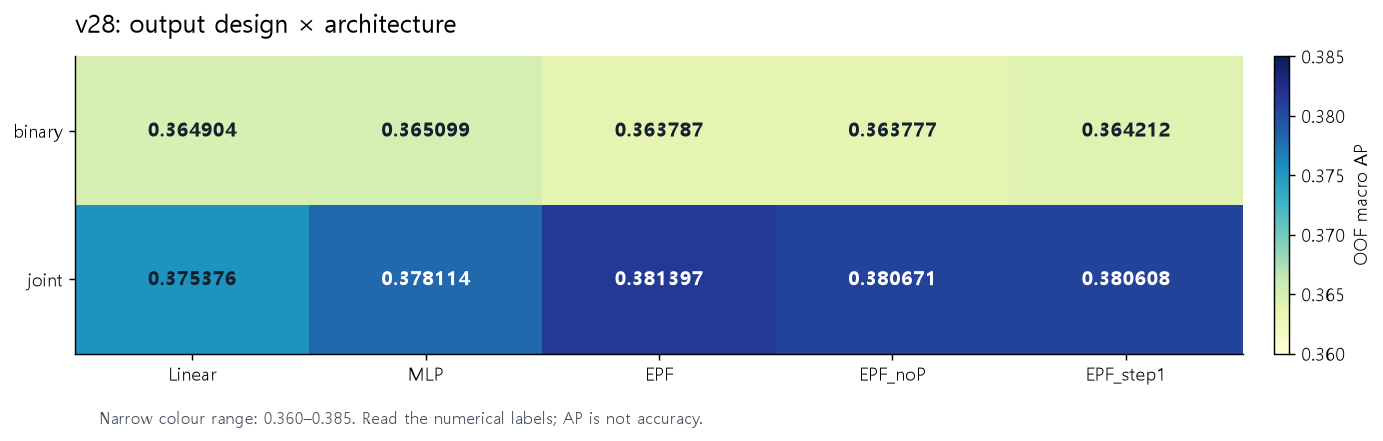

In [2]:
v28_ap_table = v28_pd.DataFrame(
    [[v28_data['cells'][f'{v28_design}_{v28_arch}']['macro_ap'] for v28_arch in v28_archs]
     for v28_design in v28_designs], index=v28_designs, columns=v28_archs)
v28_display(v28_ap_table.style.format('{:.6f}').set_caption('OOF macro AP — 높을수록 좋음'))
with v28_plt.rc_context(v28_plot_style):
    v28_fig, v28_ax = v28_plt.subplots(figsize=(10.8, 3.4))
    v28_im = v28_ax.imshow(v28_ap_table.to_numpy(), cmap='YlGnBu', vmin=.360, vmax=.385, aspect='auto')
    v28_ax.set_xticks(v28_np.arange(5), v28_archs)
    v28_ax.set_yticks(v28_np.arange(2), v28_designs)
    for v28_i in range(2):
        for v28_j in range(5):
            v28_value = float(v28_ap_table.iloc[v28_i, v28_j])
            v28_ax.text(v28_j, v28_i, f'{v28_value:.6f}', ha='center', va='center',
                        color='white' if v28_value > .376 else '#12212D', fontsize=11, fontweight='bold')
    v28_ax.set_title('v28: output design × architecture', loc='left', pad=13, fontsize=14)
    v28_fig.colorbar(v28_im, ax=v28_ax, label='OOF macro AP', fraction=.035, pad=.025)
    v28_fig.text(.075, .025, 'Narrow colour range: 0.360–0.385. Read the numerical labels; AP is not accuracy.', fontsize=9, color='#45515F')
    v28_fig.tight_layout(rect=(0, .07, 1, 1))
    v28_plt.show()


**결과:** 모든 구조에서 관측 macro AP는 joint가 binary보다 높았습니다. joint 안에서는 **EPF 0.381397**, noP 0.380671, step1 0.380608, MLP 0.378114, Linear 0.375376 순입니다. binary에서는 **MLP 0.365099**, Linear 0.364904가 EPF 0.363787보다 높았습니다.

다섯 joint−binary 대조의 평균은 **+0.014877**, PSU 95% 구간은 **[+0.005534, +0.023615]**입니다. joint 구조들의 최대−최소 범위는 **0.006020**입니다. 하나는 대조 평균이고 다른 하나는 단순 범위이므로, 두 수치를 나란히 놓은 것 자체가 ‘설계 효과가 구조 효과보다 통계적으로 크다’는 검정은 아닙니다.

다음 표는 평균 뒤를 더 자세히 봅니다. **소견별 AP**, **16상태 NLL**, **fold별 AP**를 함께 표시하여 전체 평균 하나가 가린 차이를 확인합니다.


In [3]:
v28_metric_rows = []
for v28_cell in v28_cells:
    v28_value = v28_data['cells'][v28_cell]
    v28_metric_rows.append({'비교 칸': v28_cell, 'macro AP': v28_value['macro_ap'],
                           '혈당 AP': v28_value['per_flag_ap'][0], '혈압 AP': v28_value['per_flag_ap'][1],
                           'TG AP': v28_value['per_flag_ap'][2], '낮은 HDL AP': v28_value['per_flag_ap'][3],
                           '16상태 NLL': v28_value['joint16_nll']})
v28_metric_table = v28_pd.DataFrame(v28_metric_rows).set_index('비교 칸')
v28_display(v28_metric_table.style.format('{:.6f}').set_caption('10개 칸의 전체 성능: AP ↑ / 16상태 NLL ↓'))
v28_fold_table = v28_pd.DataFrame(
    [v28_data['cells'][v28_cell]['fold_macro_ap'] for v28_cell in v28_cells],
    index=v28_cells, columns=[f'fold {v28_j}' for v28_j in range(1, 6)])
v28_display(v28_fold_table.style.format('{:.6f}').set_caption('Fold별 macro AP — 전체 OOF AP의 단순 구성 평균으로 해석하지 않음'))


,macro AP,혈당 AP,혈압 AP,TG AP,낮은 HDL AP,16상태 NLL
비교 칸,,,,,,
binary_Linear,0.364904,0.369291,0.274778,0.440659,0.374889,1.388554
binary_MLP,0.365099,0.368568,0.273949,0.441484,0.376397,1.386931
binary_EPF,0.363787,0.368230,0.274522,0.437698,0.374700,1.389019
binary_EPF_noP,0.363777,0.368295,0.274425,0.437659,0.374730,1.389031
binary_EPF_step1,0.364212,0.368023,0.275232,0.437667,0.375924,1.388051
joint_Linear,0.375376,0.378455,0.283744,0.456604,0.382702,1.359474
joint_MLP,0.378114,0.381870,0.284281,0.458722,0.387583,1.365152
joint_EPF,0.381397,0.385222,0.288002,0.463364,0.388999,1.364834
joint_EPF_noP,0.380671,0.380947,0.286890,0.464769,0.390079,1.365113


,fold 1,fold 2,fold 3,fold 4,fold 5
binary_Linear,0.387081,0.374945,0.347218,0.370144,0.412059
binary_MLP,0.387723,0.375597,0.347141,0.369816,0.410935
binary_EPF,0.387904,0.370103,0.347387,0.369393,0.412582
binary_EPF_noP,0.388237,0.370041,0.347392,0.369435,0.412581
binary_EPF_step1,0.387087,0.370941,0.347289,0.369644,0.413606
joint_Linear,0.407111,0.399494,0.347792,0.374686,0.413075
joint_MLP,0.411573,0.396608,0.356592,0.373273,0.416910
joint_EPF,0.410150,0.392860,0.366268,0.387941,0.417180
joint_EPF_noP,0.408423,0.396405,0.360458,0.385695,0.416828
joint_EPF_step1,0.408241,0.398534,0.363555,0.381480,0.417424


**16상태 NLL 결과:** joint의 다섯 구조는 낮은 값부터 **Linear 1.359474**, step1 **1.364207**, EPF **1.364834**, noP **1.365113**, MLP **1.365152** 순입니다. 따라서 **AP 최고는 EPF, 조합 NLL 최저는 Linear**라는 결과를 함께 기록합니다. 이 NLL 차이의 신뢰구간 검정은 제시된 표에서 수행하지 않았습니다.

조합 NLL에는 소견 간 의존성뿐 아니라 각 소견의 주변확률과 보정도 영향을 줍니다. NLL 한 값으로 ‘P가 의존성을 더 잘 배웠다’를 분리해 증명할 수 없습니다. 여기의 categorical NLL은 두 설계에 공통으로 적용한 **최종 16상태 평가**이며, 학습용 binary BCE와 연속값 Gaussian NLL의 수치 크기를 직접 비교한 것이 아닙니다.

**소견별 결과:** joint EPF의 혈압 AP는 **0.288002**입니다. TG와 낮은 HDL에서는 EPF 절제형의 AP가 full EPF보다 높은 칸도 있습니다. macro AP가 높다고 네 소견 모두에서 동일하게 앞선 것은 아닙니다.


### 5.5 H1: 같은 구조에서 joint가 binary보다 좋은가?

**판정 질문:** 각 구조의 `joint−binary` OOF macro AP 차이에 대해 **PSU 95% 구간 하한이 엄격히 0보다 큰가?** 전체 H1은 다섯 구조가 **모두** 이를 만족해야 합니다.

v28은 같은 사람의 고정 OOF 예측을 짝지은 상태에서 **PSU 재표집 2,000회(유효 2,000회)**로 percentile 구간을 만들었습니다. 한 번 뽑힌 집락에 속한 사람들을 함께 다뤄 집락 구조를 반영합니다.

아래 가로선은 **대조별(pointwise) 구간**입니다. 다중비교를 보정한 동시구간이 아니며, 모델 재학습·설정 선택·코호트 재사용의 불확실성까지 포함한 구간도 아닙니다. 점이 양수인 것과 하한이 0보다 큰 것은 서로 다른 조건입니다.


,AP 차이,95% 하한,95% 상한,H1 충족
구조,,,,
Linear,+0.010472,-0.000136,+0.019695,아니오
MLP,+0.013015,+0.003011,+0.021295,예
EPF,+0.017609,+0.008462,+0.026647,예
EPF_noP,+0.016894,+0.007594,+0.025583,예
EPF_step1,+0.016396,+0.007244,+0.025481,예


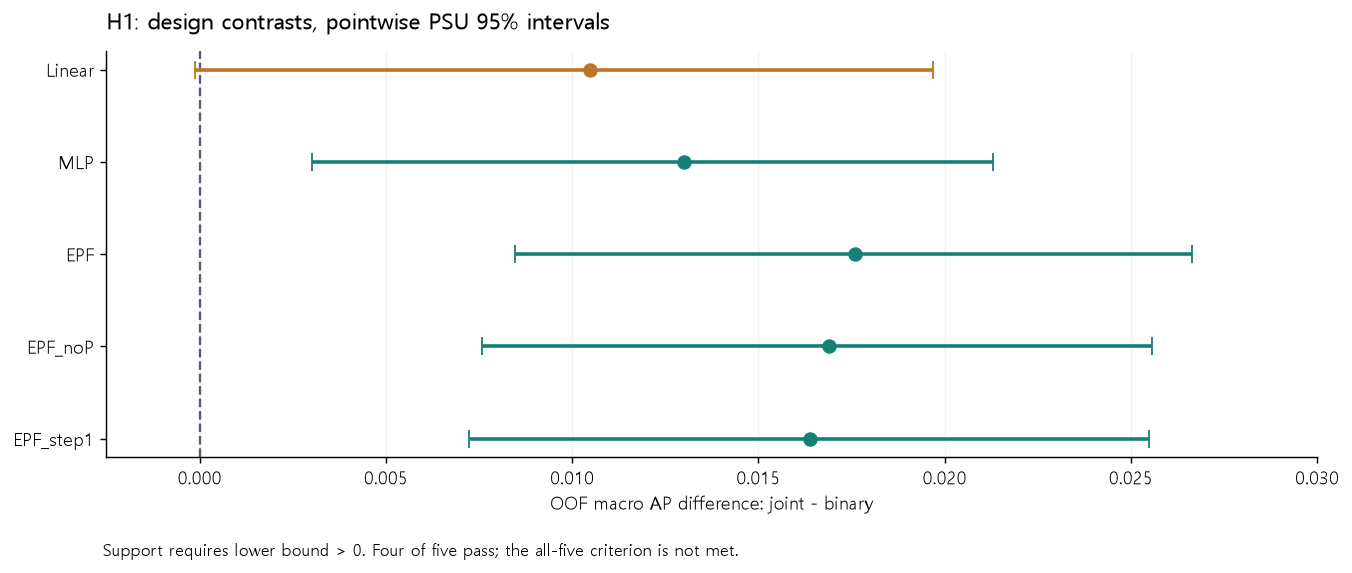

In [4]:
v28_h1_rows = []
for v28_arch in v28_archs:
    v28_contrast = v28_data['contrasts'][f'joint_{v28_arch}-binary_{v28_arch}']
    v28_h1_rows.append({'구조': v28_arch, 'AP 차이': v28_contrast['estimate'],
                       '95% 하한': v28_contrast['psu_ci95'][0], '95% 상한': v28_contrast['psu_ci95'][1],
                       'H1 충족': '예' if v28_contrast['supported'] else '아니오'})
v28_h1_table = v28_pd.DataFrame(v28_h1_rows).set_index('구조')
v28_display(v28_h1_table.style.format({v28_column: '{:+.6f}' for v28_column in ['AP 차이', '95% 하한', '95% 상한']}))
with v28_plt.rc_context(v28_plot_style):
    v28_fig, v28_ax = v28_plt.subplots(figsize=(10.5, 4.4))
    v28_ax.axvline(0, color='#526170', lw=1.3, linestyle='--')
    for v28_i, v28_arch in enumerate(v28_archs):
        v28_row = v28_h1_table.loc[v28_arch]
        v28_mid, v28_low, v28_high = (float(v28_row[v28_key]) for v28_key in ['AP 차이', '95% 하한', '95% 상한'])
        v28_color = '#168076' if v28_row['H1 충족'] == '예' else '#BD7426'
        v28_ax.errorbar(v28_mid, v28_i, xerr=[[v28_mid-v28_low], [v28_high-v28_mid]],
                       fmt='o', color=v28_color, capsize=5, markersize=7, lw=2)
    v28_ax.set_yticks(range(5), v28_archs)
    v28_ax.invert_yaxis()
    v28_ax.set_xlim(-.0025, .030)
    v28_ax.set_xlabel('OOF macro AP difference: joint - binary')
    v28_ax.set_title('H1: design contrasts, pointwise PSU 95% intervals', loc='left', pad=12)
    v28_ax.grid(axis='x', alpha=.16)
    v28_fig.text(.08, .015, 'Support requires lower bound > 0. Four of five pass; the all-five criterion is not met.', fontsize=9)
    v28_fig.tight_layout(rect=(0, .055, 1, 1))
    v28_plt.show()


**결과:** MLP·EPF·noP·step1의 **네 대조**가 H1 기준을 충족했습니다. Linear의 관측 차이는 **+0.010472**이지만 95% 하한이 **−0.000136**이므로 전체 **‘다섯 구조 모두’ H1은 미충족**입니다.

**해석:** joint의 유리한 패턴은 보이지만, 사전 전체 기준을 통과한 것으로 바꾸어 쓰면 안 됩니다. 또한 joint 전환은 연속값 감독·손실·앵커·출력 경로를 함께 바꾼 묶음입니다. 관측 개선의 원인을 공동분포 표현 하나에만 귀속하지 않습니다.


### 5.6 H2: EPF와 다른 구조의 차이가 충분히 작은가?

**판정 질문:** `joint EPF−joint X`의 **90% 구간 전체가 열린 범위 (−0.005, +0.005)** 안에 있는가? 경계에 닿아도 미충족입니다. 이 ±0.005는 연구에서 사전 지정한 macro AP 한계이며 임상적으로 합의된 허용 오차라는 뜻은 아닙니다.

H2는 차이가 정확히 0인지 묻는 검정과 다릅니다. **0을 포함한다고 동등한 것이 아니고, 0을 포함하지 않는다고 반드시 한계 밖인 것도 아닙니다.** 가로선 전체가 옅은 영역 안에 들어오는지를 봅니다.

주된 구조 절제 조건은 **noP와 step1 둘 다**를 대상으로 합니다. MLP·Linear를 포함한 **네 대조 모두 사전 지정한 H2 대조**이며, 네 구조 전체 조건도 함께 확인합니다. H1과 동일하게 고정 OOF 예측의 대조별 PSU 구간이라는 해석 범위가 적용됩니다.


,EPF − X,90% 하한,90% 상한,H2 충족
비교 구조 X,,,,
EPF_noP,+0.000725,-0.001095,+0.002714,예
EPF_step1,+0.000789,-0.001726,+0.003580,예
MLP,+0.003283,-0.000244,+0.007566,아니오
Linear,+0.006020,+0.001540,+0.011444,아니오


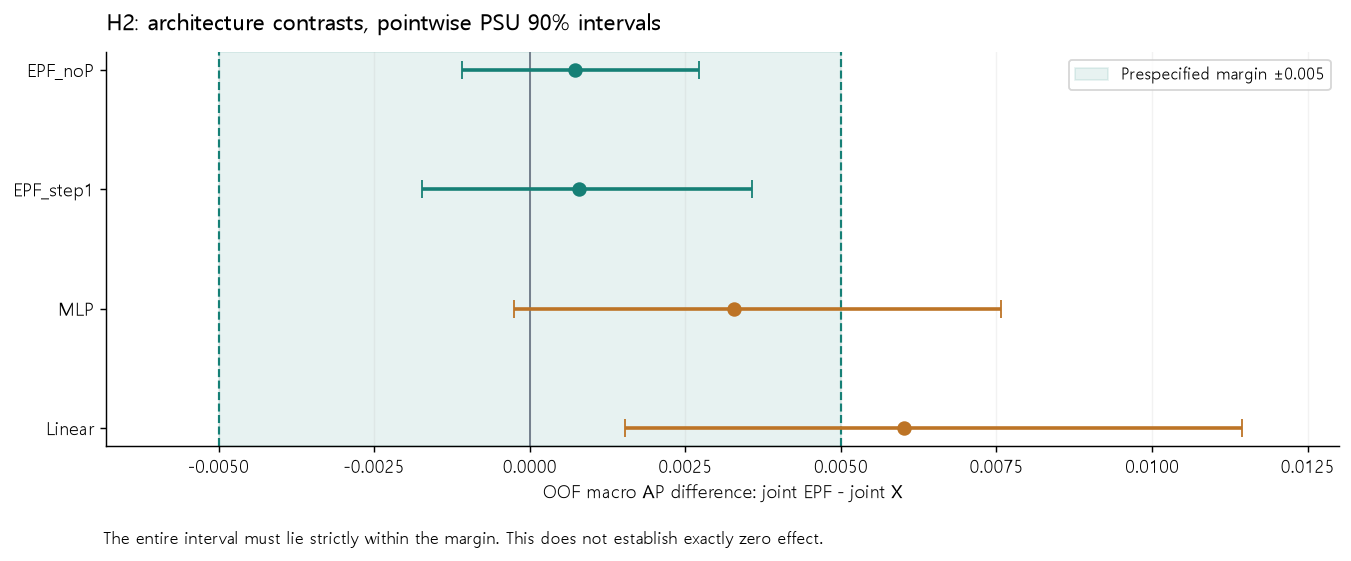

In [5]:
v28_h2_archs = ['EPF_noP', 'EPF_step1', 'MLP', 'Linear']
v28_h2_rows = []
for v28_arch in v28_h2_archs:
    v28_contrast = v28_data['contrasts'][f'joint_EPF-joint_{v28_arch}']
    v28_h2_rows.append({'비교 구조 X': v28_arch, 'EPF − X': v28_contrast['estimate'],
                       '90% 하한': v28_contrast['psu_ci90'][0], '90% 상한': v28_contrast['psu_ci90'][1],
                       'H2 충족': '예' if v28_contrast['supported'] else '아니오'})
v28_h2_table = v28_pd.DataFrame(v28_h2_rows).set_index('비교 구조 X')
v28_display(v28_h2_table.style.format({v28_column: '{:+.6f}' for v28_column in ['EPF − X', '90% 하한', '90% 상한']}))
with v28_plt.rc_context(v28_plot_style):
    v28_fig, v28_ax = v28_plt.subplots(figsize=(10.5, 4.3))
    v28_margin = float(v28_data['rules']['equivalence_margin'])
    v28_ax.axvspan(-v28_margin, v28_margin, color='#168076', alpha=.10, label='Prespecified margin ±0.005')
    v28_ax.axvline(0, color='#6B7785', lw=1)
    for v28_boundary in [-v28_margin, v28_margin]:
        v28_ax.axvline(v28_boundary, color='#168076', lw=1.2, linestyle='--')
    for v28_i, v28_arch in enumerate(v28_h2_archs):
        v28_row = v28_h2_table.loc[v28_arch]
        v28_mid, v28_low, v28_high = (float(v28_row[v28_key]) for v28_key in ['EPF − X', '90% 하한', '90% 상한'])
        v28_color = '#168076' if v28_row['H2 충족'] == '예' else '#BD7426'
        v28_ax.errorbar(v28_mid, v28_i, xerr=[[v28_mid-v28_low], [v28_high-v28_mid]],
                       fmt='o', color=v28_color, capsize=5, markersize=7, lw=2)
    v28_ax.set_yticks(range(4), v28_h2_archs)
    v28_ax.invert_yaxis()
    v28_ax.set_xlim(-.0068, .013)
    v28_ax.set_xlabel('OOF macro AP difference: joint EPF - joint X')
    v28_ax.set_title('H2: architecture contrasts, pointwise PSU 90% intervals', loc='left', pad=12)
    v28_ax.grid(axis='x', alpha=.16)
    v28_ax.legend(loc='upper right', fontsize=9)
    v28_fig.text(.08, .015, 'The entire interval must lie strictly within the margin. This does not establish exactly zero effect.', fontsize=9)
    v28_fig.tight_layout(rect=(0, .055, 1, 1))
    v28_plt.show()


**결과:** noP·step1은 두 구간 모두 한계 안에 들어왔고, MLP·Linear는 전체 구간이 한계 안에 들어오지 못했습니다.

| 사전 조건 | 결과 | 이유 |
|---|---|---|
| H1 다섯 구조 모두 | **미충족** | Linear의 95% 하한이 0보다 크지 않음 |
| H2 noP·step1 모두 | **충족** | 두 90% 구간 전체가 ±0.005 안에 있음 |
| H2 네 비교 구조 전체 | **미충족** | MLP·Linear 구간이 한계 밖으로 나감 |
| H1 전체 + H2 noP·step1의 주된 결합 기준 | **미충족** | H1 전체가 빠짐 |
| 네 비교 구조까지의 확장 결합 기준 | **미충족** | 전체 조건을 함께 충족하지 못함 |

**해석:** 이 코호트·지표·한계·학습 예산에서 두 절제형과 full EPF의 차이가 작은 범위에 들어왔습니다. 모든 지표가 동등하다거나 P가 언제나 불필요하다는 결론은 아닙니다. 반대로 MLP·Linear의 H2 미충족도 곧바로 성능 차이의 존재를 입증한 결과는 아닙니다.


### 5.7 학습은 언제 멈췄고 모델은 얼마나 컸나?

**질문:** 성능표의 모델들은 얼마나 학습한 상태에서 선택되었는가?

각 비교 칸은 **100 학습 단위(4설정×5seed×5fold)**를 수행하고 최종 **25 checkpoint(5seed×5fold)**를 선택합니다. 아래 평균·중앙 best epoch와 epoch 1 개수는 **선택된 25개** 기준입니다.

파라미터 수는 `requires_grad`가 켜진 숫자의 개수입니다. 실제로 모두 비영 기울기를 받았다는 확인, 같은 유효 용량이나 추론 속도의 증거와는 구분합니다.


In [6]:
v28_epoch_rows = []
for v28_cell in v28_cells:
    v28_value = v28_data['cells'][v28_cell]
    v28_epoch_rows.append({'비교 칸': v28_cell, '파라미터 수': v28_value['parameters'][0],
                          '전체 학습 단위': v28_value['training_units'], '선택 단위': v28_value['selected_units'],
                          '평균 best epoch': v28_value['selected_mean_best_epoch'],
                          '중앙 best epoch': v28_value['selected_median_best_epoch'],
                          'epoch 1 / 선택': f"{v28_value['selected_best_epoch_one_count']}/{v28_value['selected_units']}"})
v28_epoch_table = v28_pd.DataFrame(v28_epoch_rows).set_index('비교 칸')
v28_display(v28_epoch_table.style.format({'파라미터 수': '{:,}', '평균 best epoch': '{:.2f}', '중앙 best epoch': '{:.1f}'}))


,파라미터 수,전체 학습 단위,선택 단위,평균 best epoch,중앙 best epoch,epoch 1 / 선택
비교 칸,,,,,,
binary_Linear,460,100,25,1.84,1.0,15/25
binary_MLP,"8,212",100,25,7.68,7.0,5/25
binary_EPF,"5,895",100,25,3.20,1.0,17/25
binary_EPF_noP,"5,893",100,25,3.16,1.0,17/25
binary_EPF_step1,"5,895",100,25,7.16,8.0,9/25
joint_Linear,654,100,25,53.52,59.0,0/25
joint_MLP,"8,708",100,25,14.88,15.0,0/25
joint_EPF,"5,971",100,25,8.60,9.0,0/25
joint_EPF_noP,"5,969",100,25,8.28,9.0,0/25


**결과:** binary EPF는 선택 모델 **17/25**의 best epoch가 1이고 평균 **3.20**, 중앙값 **1**입니다. joint EPF는 **0/25**, 평균 **8.60**, 중앙값 **9**입니다.

이는 두 설계에서 validation 점수가 가장 좋았던 시점이 달랐다는 기록입니다. epoch 1도 **한 epoch의 업데이트 뒤 평가한 값**이므로 전혀 학습하지 않았다거나 선형 앵커가 움직이지 않았다는 뜻은 아닙니다.

step1은 저장된 학습 가능 파라미터가 있어도 한 단계 계산에서 출력에 영향을 주지 않는 동역학 경로가 남습니다. 따라서 표의 파라미터 개수와 실제 작동 경로를 구분합니다. 속도나 전력 우열을 확인하려면 같은 하드웨어·배치 조건의 별도 측정이 필요합니다.


<a id="part-6"></a>
## 6부. 결론, 한계, 다시 읽고 실행하는 방법
### 6.1 무엇을 확인했고 어디까지 말할 수 있는가?

초기 분석은 **11개 비침습 입력으로 소견 하나 이상을 예측하는 기준선**을 보여 주었습니다. 후속 연구는 **검사값 공동분포와 EPF의 내부 계산을 연결하고, 설계×구조 비교로 검증 질문을 분리**했습니다. v28의 관측 AP 최고는 joint EPF, 16상태 NLL 최저는 joint Linear였습니다. H1은 4/5, 주된 H2 두 대조는 충족했지만 전체 결합 기준은 미충족입니다.

| 남은 경계 | 현재 결과에 적용되는 의미 | 다음 확인에서 필요한 것 |
|---|---|---|
| 초기 정답·대상 | 치료 제외와 미인지가 다름; 검사값 결측·공복 조건 문제 | 대상 용어를 맞추고 정답 완전성·공복 기준을 먼저 고정 |
| 초기 평가·추론 | 한 번의 분할, 시험에서 기준 선택, 근사 OR 구간 | 학습 내부 기준 선택, 독립 평가, 적합과 일치하는 추론·조사 설계 반영 |
| v28의 불확실성 | 개발 코호트 재사용, 고정 OOF 조건부 구간 | 독립 외부 코호트와 재학습·선택 변동을 포함한 확인 |
| 분포 가정 | Gaussian·rank-one 공분산, 제한된 입력 의존 scale | 분포 적합과 보정의 별도 평가 |
| 임상 사용 | AP·NLL만으로 실제 선별 효용을 확정할 수 없음 | 고정 기준의 민감도·특이도·보정·순편익과 하위집단 안정성 |
| 기전·인과 | P·loading·OR·집단 차이는 생물학적 원인의 직접 증거가 아님 | 목적에 맞는 인과 설계나 별도 기전 검증 |
| 실제 운용 | 같은 조건의 지연시간·전력·현장 성능을 측정하지 않음 | 실행 조건을 고정한 측정과 외부 검증 |

자료는 **횡단면 관측**입니다. 미래 발병·개인 장기 경과를 검증한 모델이나 승인·배포가 끝난 임상 도구로 해석하지 않습니다. 이 경계를 유지하면 구현의 특징과 실제 성능 증거를 과장 없이 함께 설명할 수 있습니다.


<a id="references"></a>
### 6.2 선행연구와 이 구현의 관계

개별 원리는 관련 선행연구와 연결됩니다. 아래 다섯 1차자료는 **무엇을 참고했고 무엇이 다른지**를 구분하기 위한 출처입니다.

| 1차자료 | 알려진 원리 / 이 구현과의 관계 |
|---|---|
| [Gorishniy 등, NeurIPS 2021](https://papers.nips.cc/paper/2021/hash/9d86d83f925f2149e9edb0ac3b49229c-Abstract.html) | 표 자료 신경망을 강한 기준선과 비교해야 한다는 논점. v28은 Linear·MLP 대조를 사용하지만 모든 표 자료·트리 모델에 대한 우월성 검증은 아님 |
| [Gneiting & Raftery, JASA 2007](https://doi.org/10.1198/016214506000001437) | 확률 예측을 proper scoring rule로 평가하는 이론. Gaussian·categorical NLL의 근거와 연결되며, NLL 사용 자체가 보정의 증거는 아님 |
| [Neftci·Mostafa·Zenke, 2019](https://arxiv.org/abs/1901.09948) | 불연속 사건을 대리 기울기로 학습하는 원리. EPF는 hard event의 backward에 이를 사용하며 실제 생체 신경세포 재현을 주장하지 않음 |
| [Helfrich·Willmott·Ye, ICML 2018](https://proceedings.mlr.press/v80/helfrich18a.html) | 실수 scaled Cayley 기반 직교 recurrent 가중치 매개화. 복소 Hermitian 상태 전달을 쓰는 여기와 같은 모델은 아니며 norm 제어 변환 원리가 관련됨 |
| [Lakshminarayanan·Pritzel·Blundell, NeurIPS 2017](https://arxiv.org/abs/1612.01474) | 여러 신경망의 확률 예측을 결합하는 deep ensemble. 다섯 seed 분포 평균과 연결되며 seed 평균 자체를 새 기법으로 주장하지 않음 |

학술적 차이를 평가할 때 **구성을 구현했다는 사실**과 **그 구성 때문에 성능이 좋아졌다는 증거**를 분리합니다. 전자는 모델 소스, 후자는 v28 대조와 구간으로 확인합니다.


<a id="reproduce"></a>
### 6.3 원하는 범위만 실행하고 근거 확인하기

| 목적 | 실행·확인 방법 |
|---|---|
| 문서와 기존 결과만 읽기 | 저장된 표·그림을 읽으면 됨. 실행 불필요 |
| 후반부 집계 그림 다시 만들기 | [5.3 집계 준비](#aggregate-start)의 첫 코드부터 뒤 코드 셀을 순서대로 실행. `numpy`, `pandas`, `matplotlib`, `IPython` 필요 |
| 초기 분석 재실행 | 2부부터 원자료·필요 패키지를 준비하고 순서대로 실행. `Run All`은 원자료 접근과 초기 모델 학습도 포함 |
| 모델 핵심 점검 | 준비된 114열 배열을 받는 공개 모델 API와 구현을 확인 |

초기 재실행에는 `pyreadstat`, `scikit-learn`, `xgboost`, `lightgbm`, `scipy`, `seaborn` 등 해당 셀의 패키지도 필요합니다. 일부 저장 출력은 개인별 자료·환경 경고 등을 정리한 공개본으로, 현재 코드의 모든 출력이 저장되어 있지는 않을 수 있습니다. **이번 편집은 기존 21개 코드 셀의 소스·출력·실행 번호·ID를 그대로 보존했고 초기 학습이나 개인별 지표를 재계산하지 않았습니다.**

Windows에서 초기 그래프 한글이 깨지면 새 실행 환경의 글꼴 설정으로 `plt.rcParams['font.family'] = 'Malgun Gothic'`, `plt.rcParams['axes.unicode_minus'] = False` 등을 적용할 수 있습니다. 저장된 원본 그림은 그대로 남아 있습니다.

| 근거 | 연결 |
|---|---|
| v28 성능·H1/H2·epoch | [PUBLIC_REPORT.json](../v28/PUBLIC_REPORT.json), [REPORT.md](../v28/REPORT.md), [PROTOCOL.md](../v28/PROTOCOL.md) |
| 모델 호출·앵커·학습 | [experiment.py](../models/clinical_v28/experiment.py), [모델 API 계약](../models/clinical_v28/README.md) |
| 사건·흔적·P | [event_field_v21.py](../models/clinical_v28/event_field_v21.py), [event_plastic_field.py](../models/clinical_v28/event_plastic_field.py) |
| 평균·공분산 head | [event_field_v23.py](../models/clinical_v28/event_field_v23.py) |
| 좌표·확률 변환과 혼합 | [clinical_v23_distribution.py](../models/clinical_v28/clinical_v23_distribution.py), [clinical_v24_distribution.py](../models/clinical_v28/clinical_v24_distribution.py) |
| v26 후보 집계 | 5.1 표와 아래 원 보고서 SHA256 |

상대 링크는 저장소의 `notebooks/` 위치 기준입니다. 노트북 하나만 받아도 저장 결과와 내장 집계 재실행은 가능하지만 소스 링크는 저장소 구조가 함께 있어야 열립니다.

공개 모델 패키지는 원자료·역할 인덱스·fit 전처리 자산·기존 앵커·학습된 checkpoint를 포함하지 않으므로 **원 코호트의 1,000회 학습 전체를 그대로 재현하는 패키지는 아닙니다.** 합성 입력의 forward나 테스트 통과도 보고된 성능 재현을 대신하지 않습니다.

아래 SHA256은 어떤 산출물에서 왔는지 확인하기 위한 식별값입니다. 이전 70셀 확장본의 소스·기준선·동결 study/selection/training/evaluation 해시와 실행 기록은 `metadata.revision_history`의 `prior_70_cell_extension` 항목에 보존했습니다. 그 안의 셀 위치와 builder 해시는 **이전 확장 당시 기록**입니다. 이번 편집의 원본·builder 해시, 현재 집계 시작 위치, 코드 보존 장부는 `metadata.editorial_v2`에 있습니다. 해시 일치는 산출물의 동일성을 확인하며 과학적 타당성 자체를 보장하지는 않습니다.


In [7]:
v28_source_rows = [
    {'산출물': 'v28 공개 집계 JSON', 'SHA256': v28_provenance['public_source_sha256']['v28/PUBLIC_REPORT.json']},
    {'산출물': 'v28 원 보고서 (공개 집계가 참조)', 'SHA256': v28_provenance['frozen_artifacts']['report_sha256']},
    {'산출물': 'v28 선택 동결', 'SHA256': v28_provenance['frozen_artifacts']['selection_freeze_sha256']},
    {'산출물': 'v28 평가 완료', 'SHA256': v28_provenance['frozen_artifacts']['evaluation_done_sha256']},
    {'산출물': 'v26 후보 보고서', 'SHA256': v28_provenance['v26_report_sha256']},
]
v28_display(v28_pd.DataFrame(v28_source_rows).set_index('산출물'))


,SHA256
산출물,
v28 공개 집계 JSON,d9f002961a12e16c1ced71f82940be3a051c66ac295237...
v28 원 보고서 (공개 집계가 참조),c04afe08c4c8a15c6a1cc5d4ca692d60fc222b0d36f28e...
v28 선택 동결,b07201f2c6b01ee47e143c31d65a1a41af6fa11ecf55b6...
v28 평가 완료,6722d4f13580a60660feff397b2c1dd7490f361d8ce293...
v26 후보 보고서,05d5c5a6c8343f85769bfa4df8a97009cb840e3fb91954...
